In [1]:
import Data_Utils
import Save_Utils
import VotingResult
import SoD_Utils
import numpy as np
import pandas as pd
import Utils
import Visualization_Utils

In [2]:
# MODEL = Data_Utils.GPT_41_NANO
# MODEL = Data_Utils.GPT_4o_MINI
# MODEL = Data_Utils.GPT_41
MODEL = Data_Utils.GPT_4o

processor = Utils.VotingProcessor()

In [3]:
def decline_region_to_Genitiv(region_name):
    if 'Česko' in region_name:
        return 'Česka'
    # Handles special case for Prague 'Hlavní město Praha'
    if 'Praha' in region_name:
        return 'Prahy'

    # General grammar rules for other regions
    declined_name = region_name.replace('raj', 'raje')  # Covers Kraj and kraj
    if 'ký' in declined_name:
        declined_name = declined_name.replace('ký', 'kého')

    return declined_name

In [4]:
def citizen_prompt(region):
    return "Jsem obyvatel/ka "+ decline_region_to_Genitiv(region) + ". Ve volbách do poslanecké sněmovny v roce 2021 jsem volil:"
def direct_prompt(region):
    return "Účast a výsledek voleb do poslanecké sněmovny v "+ SoD_Utils.decline_region_to_Locative(region)+" v roce 2021 budou:"


In [5]:
print(citizen_prompt("Česko"))
print(direct_prompt("Česko"))

Jsem obyvatel/ka Česka. Ve volbách do poslanecké sněmovny v roce 2021 jsem volil:
Účast a výsledek voleb do poslanecké sněmovny v Česku v roce 2021 budou:


In [6]:
n = 10
prompt = citizen_prompt
# prompt = direct_prompt

In [ ]:
latent_results = []
for region in ["Česko"] + Data_Utils.REGIONS:
    voting_results, skipped = processor.run(
        data=pd.DataFrame(np.random.rand(n, 1), columns=['Col']),
        prompt_creator= lambda res: prompt(region),
        response_model= VotingResult.VotingProbabilities,
        model= MODEL, temperature = 0,
    )
    results_df = Save_Utils.results_to_dataframe(voting_results)
    model_latent_result = Data_Utils.aggregate_results_from_df(results_df)
    model_latent_result['region'] = region
    latent_results.append(model_latent_result)

latent_results_df = pd.DataFrame(latent_results)
latent_results_df.to_csv(f"results/LatentPreferences_{MODEL}_{prompt.__name__}.csv")

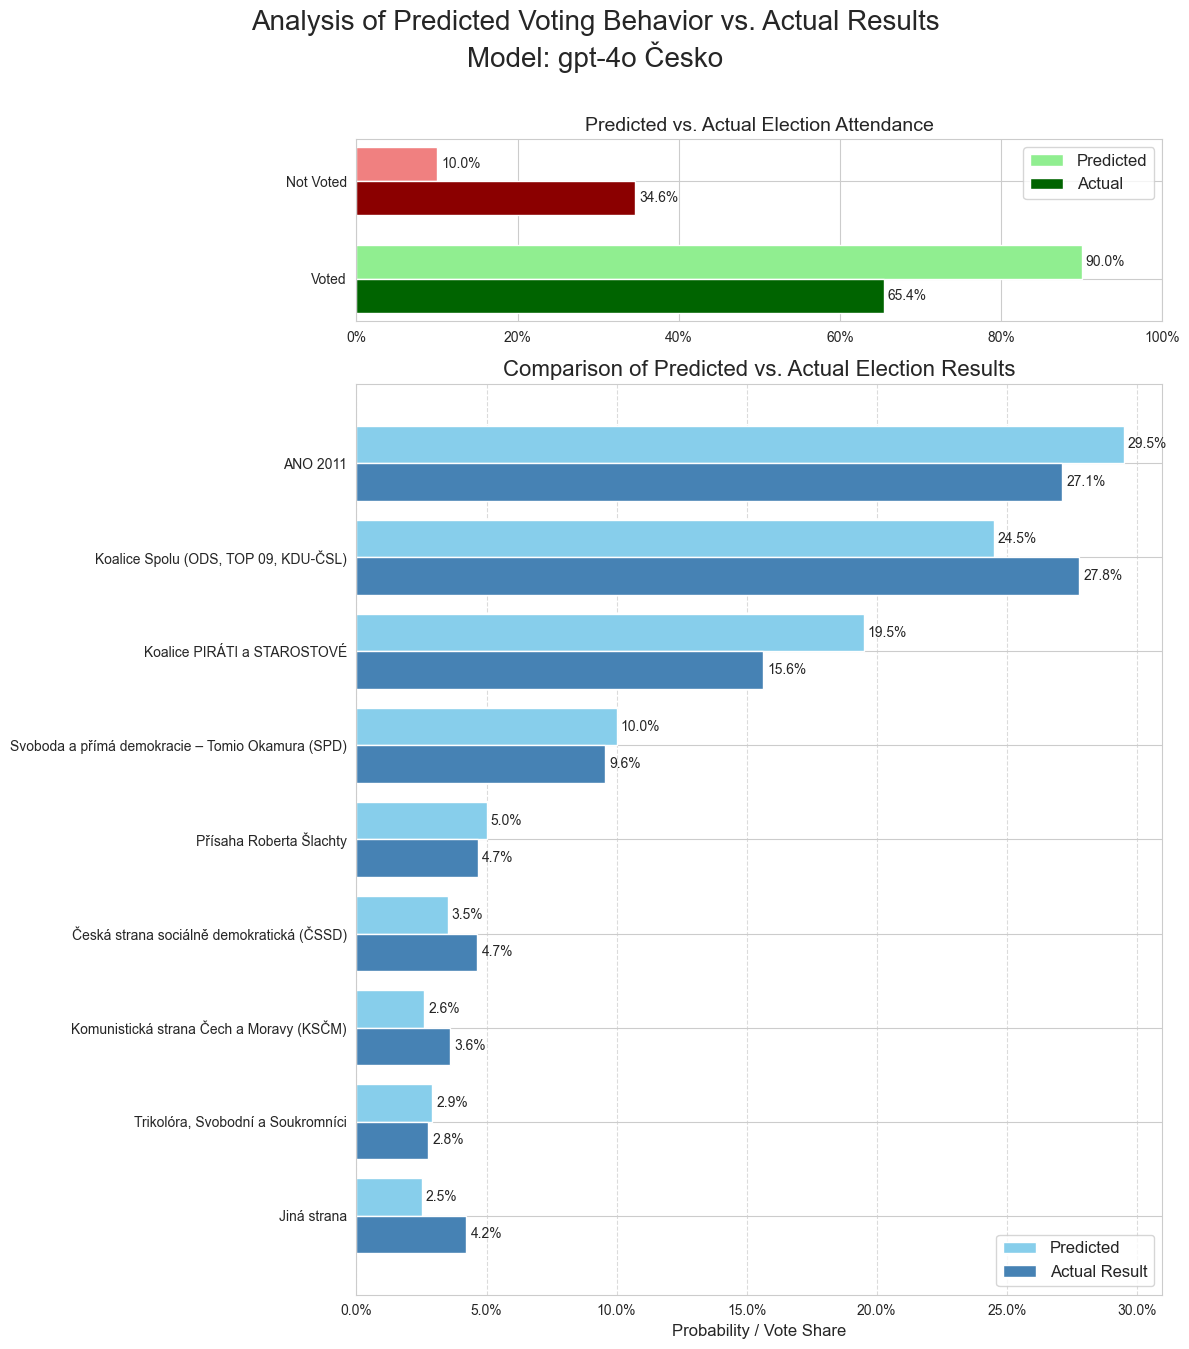

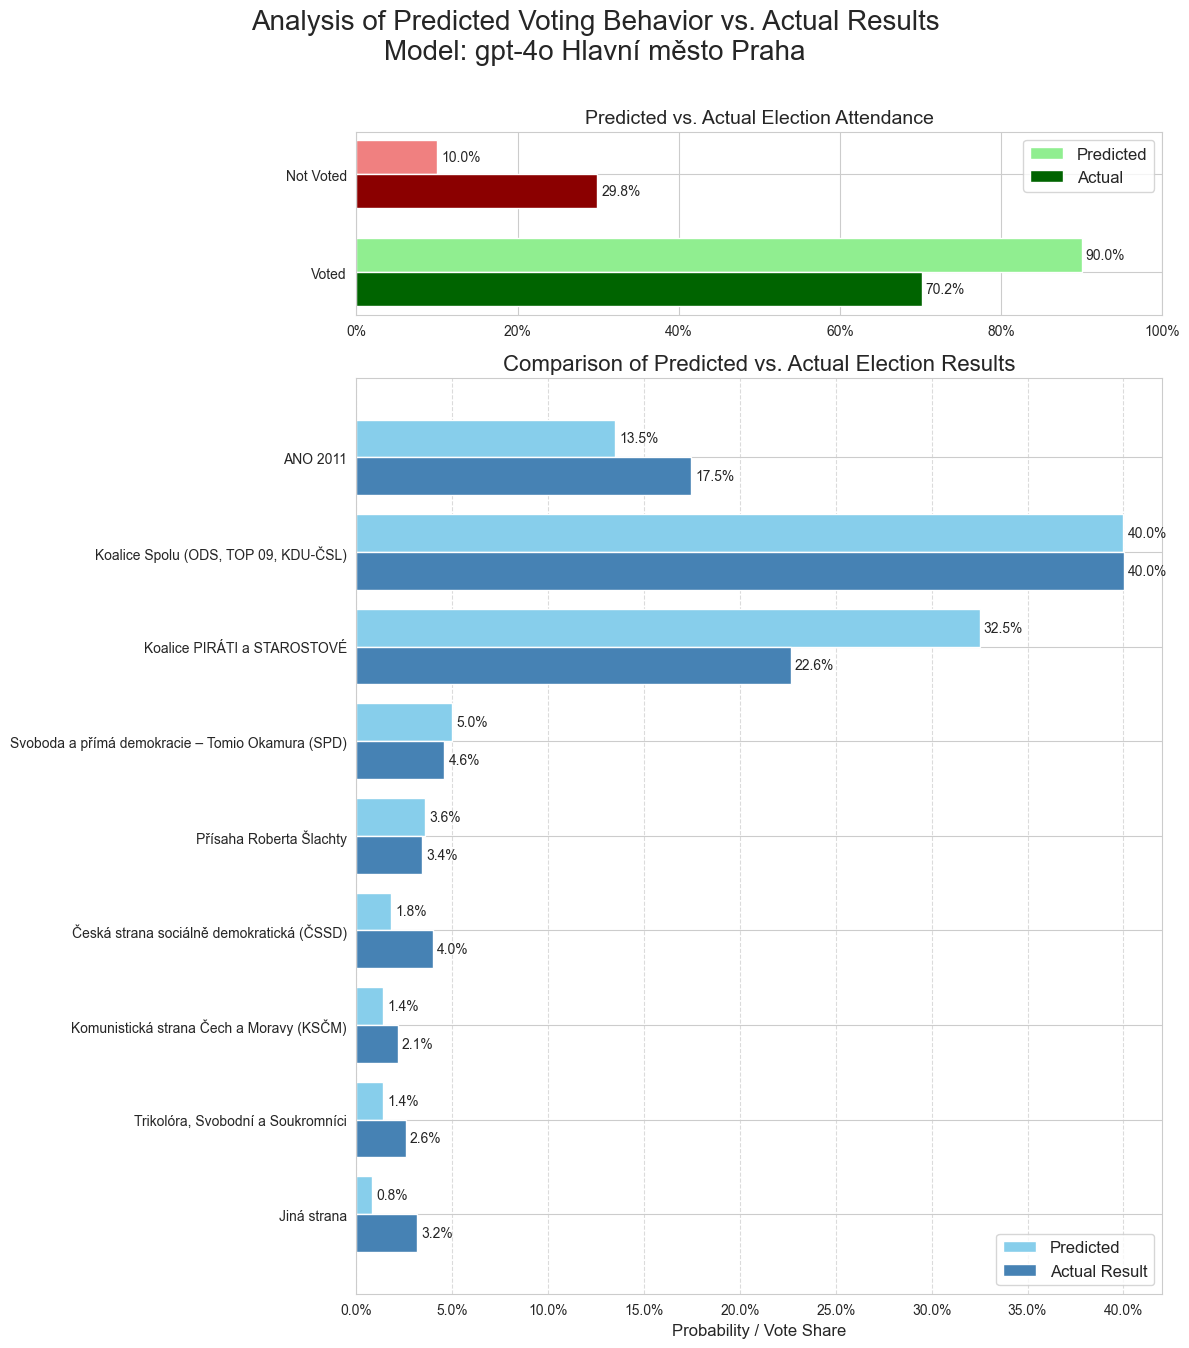

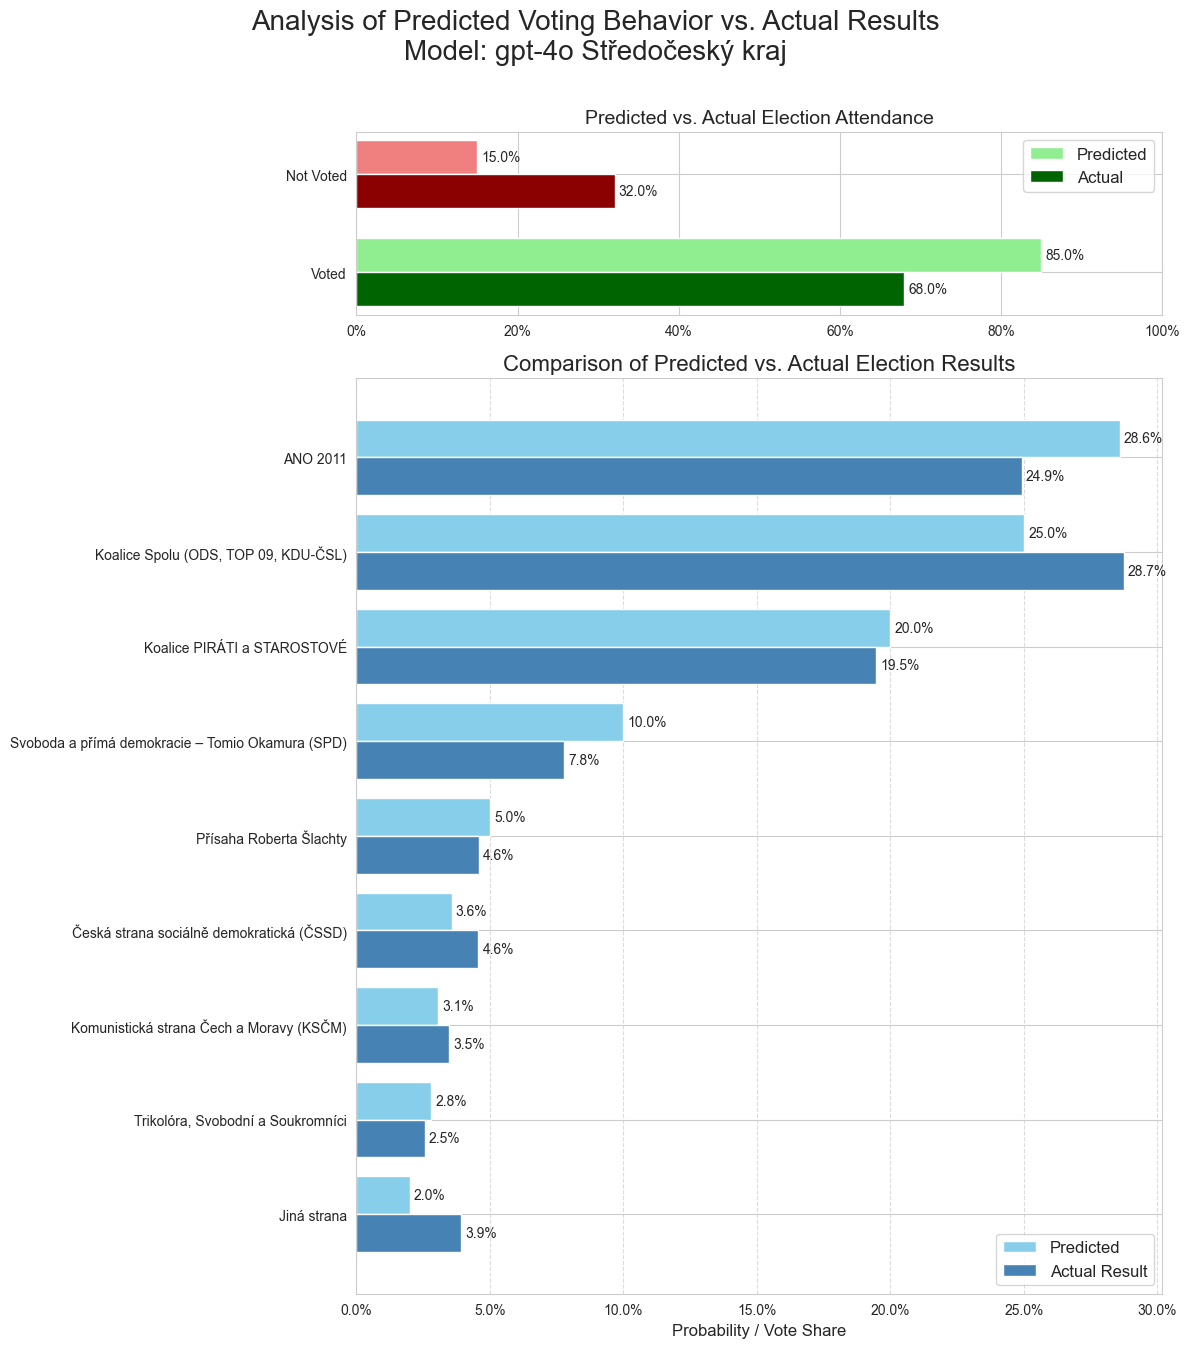

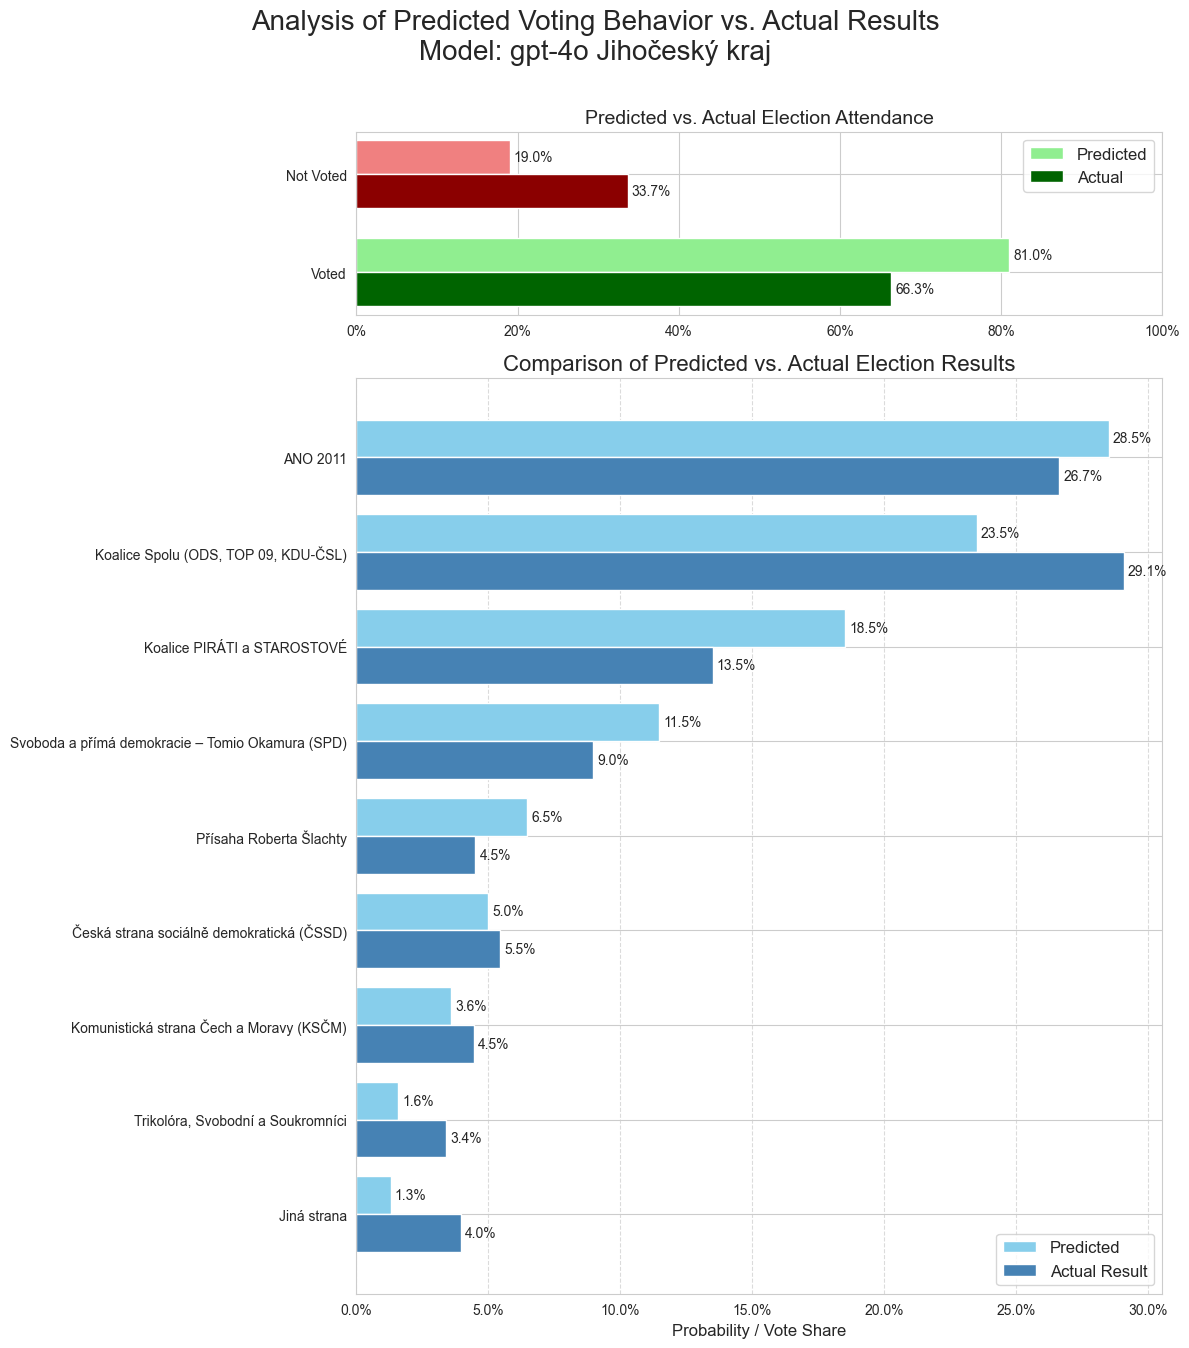

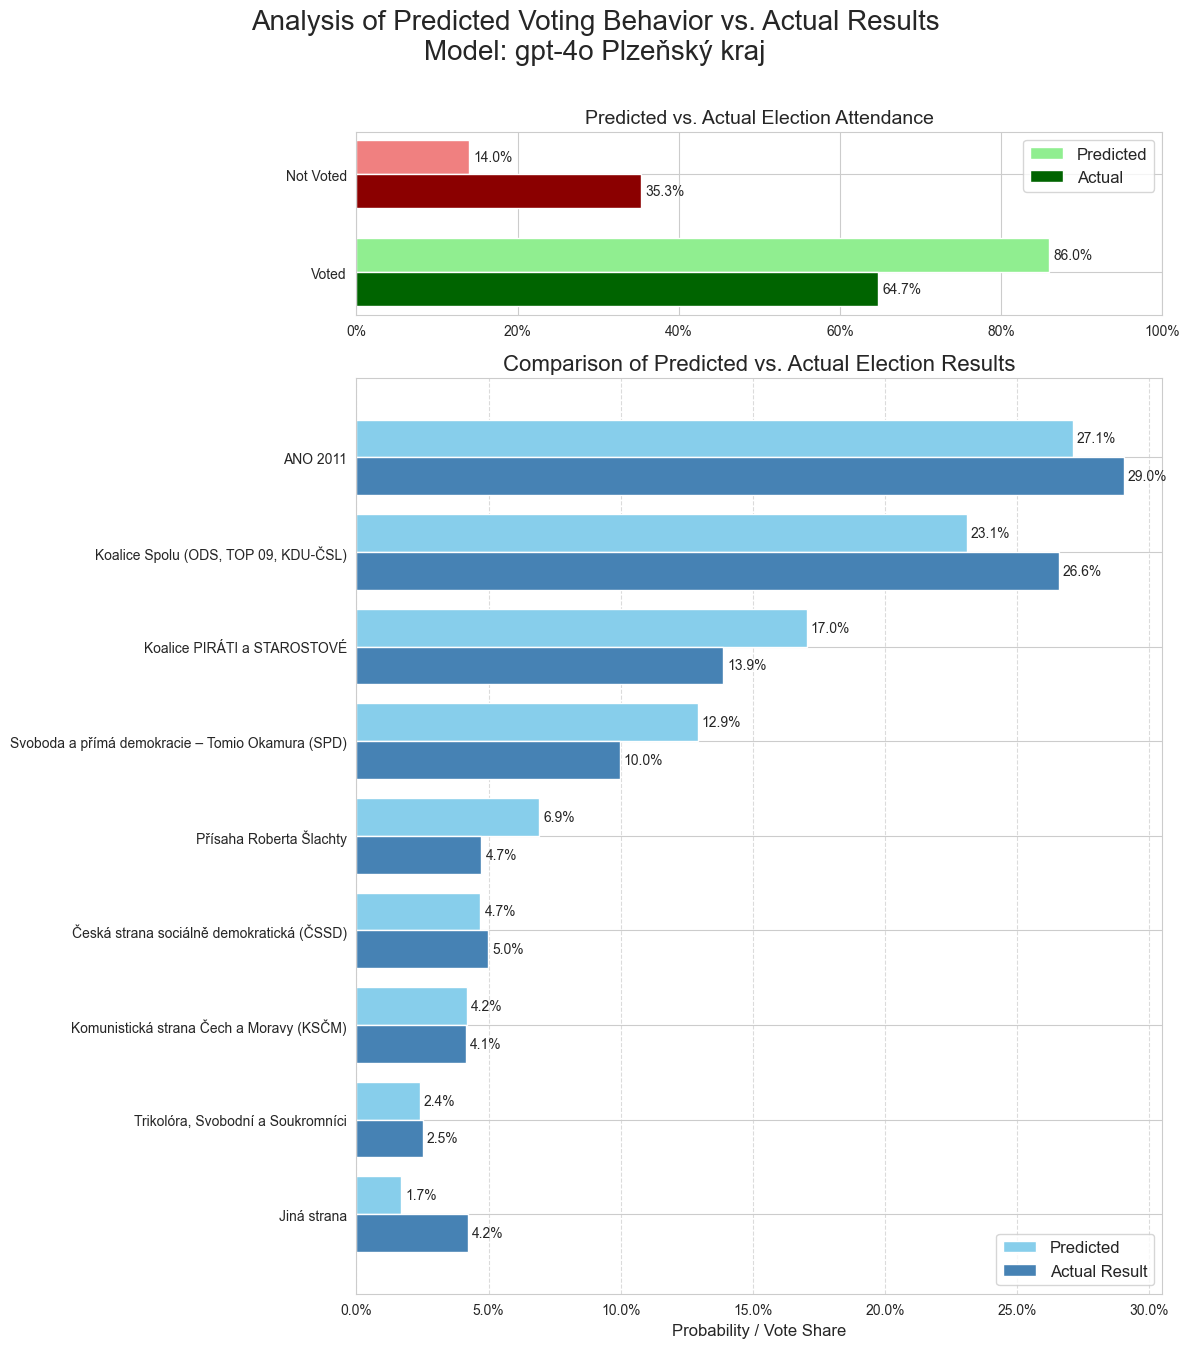

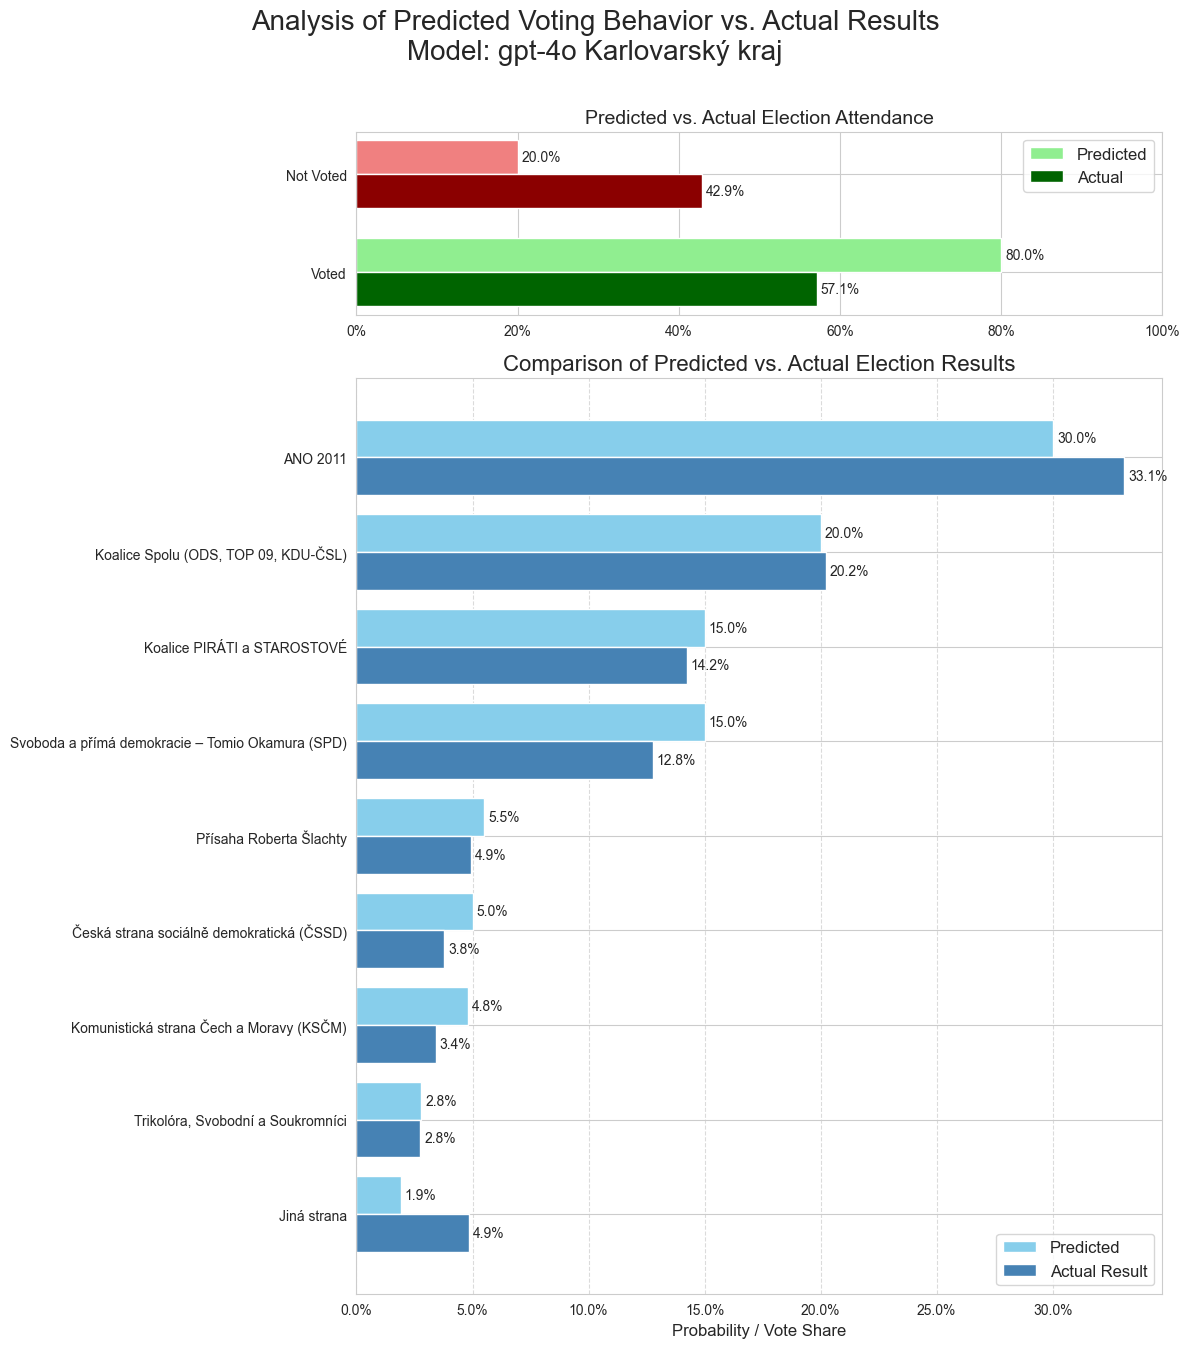

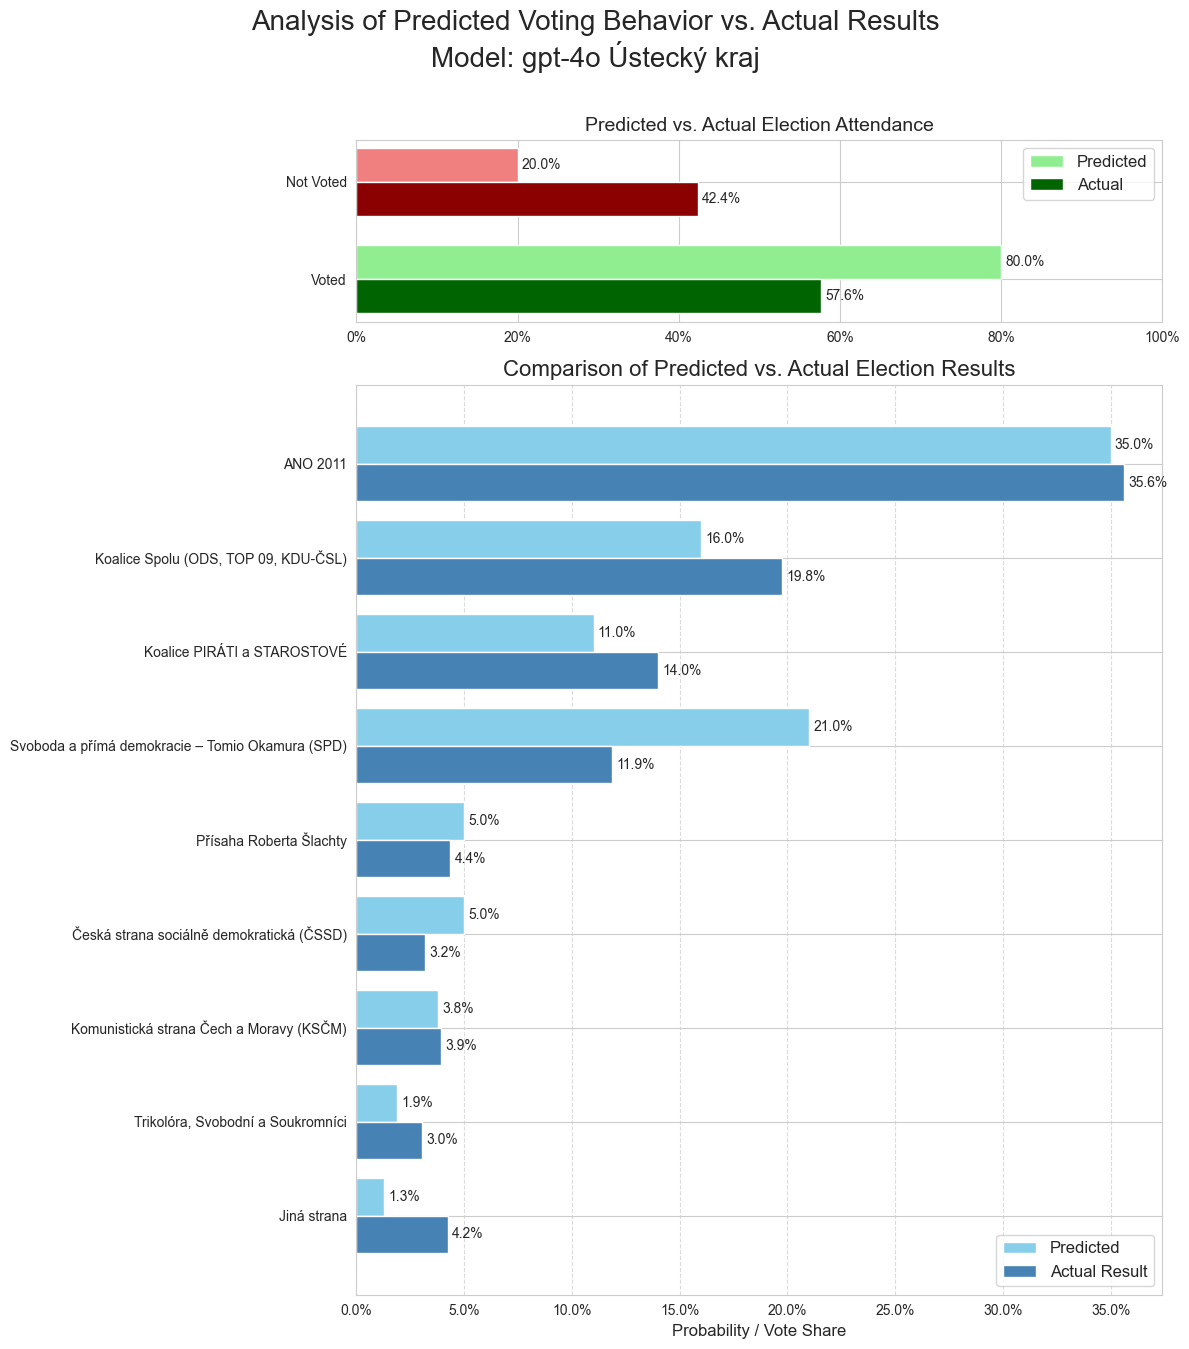

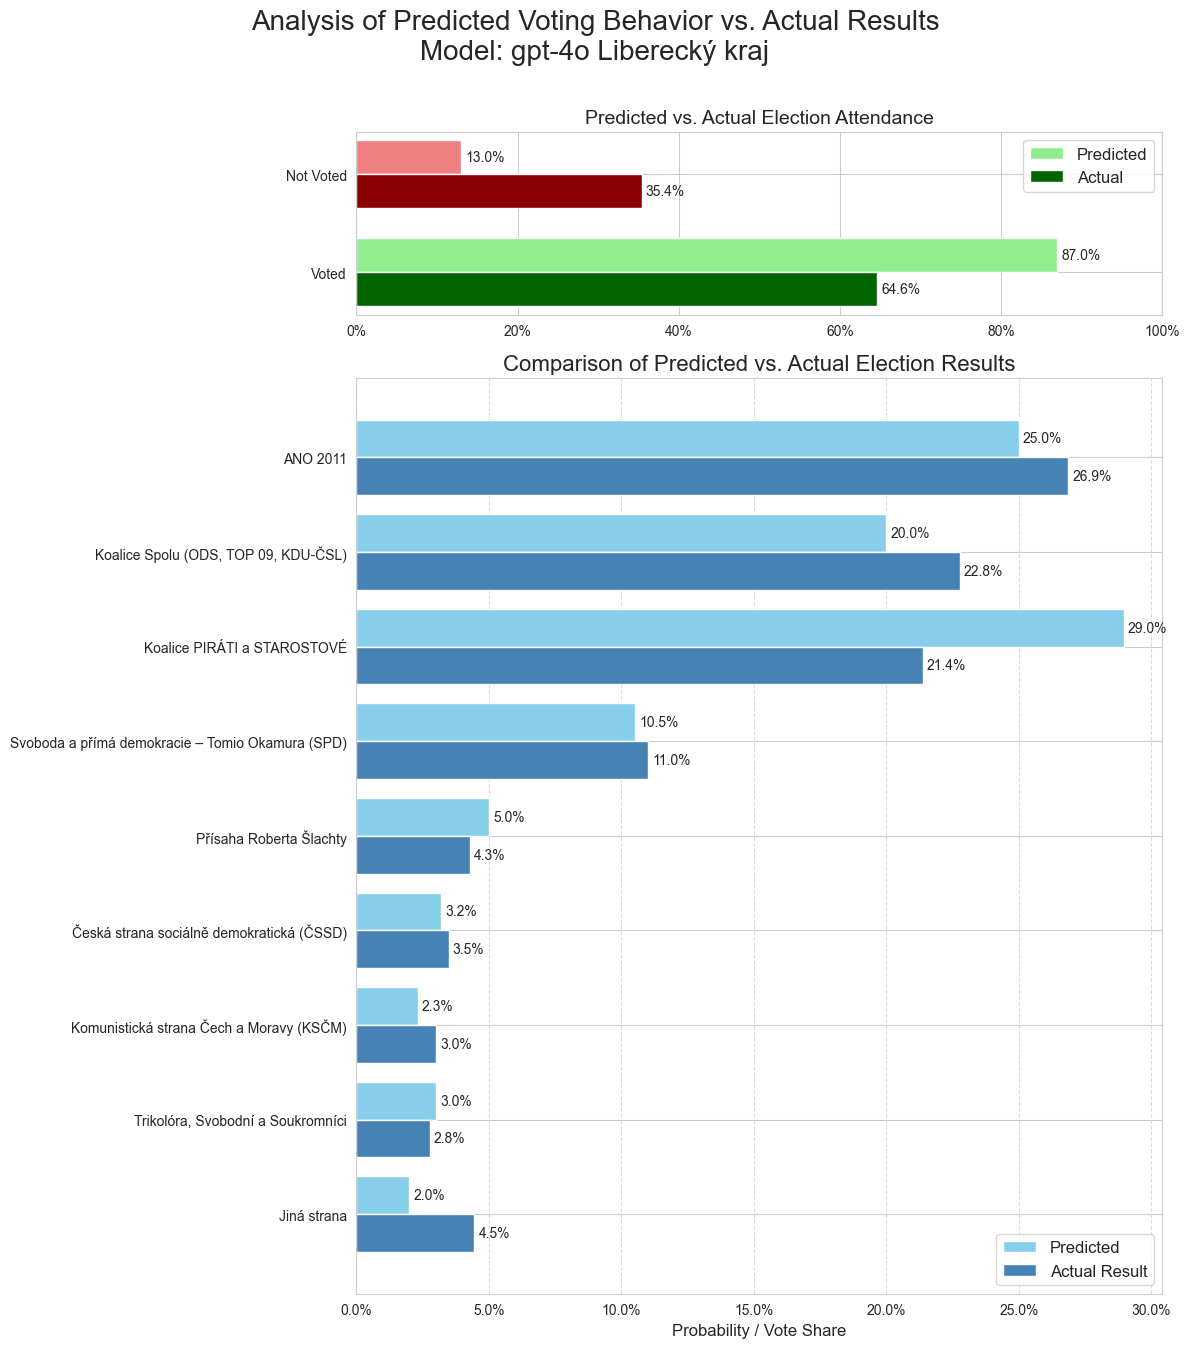

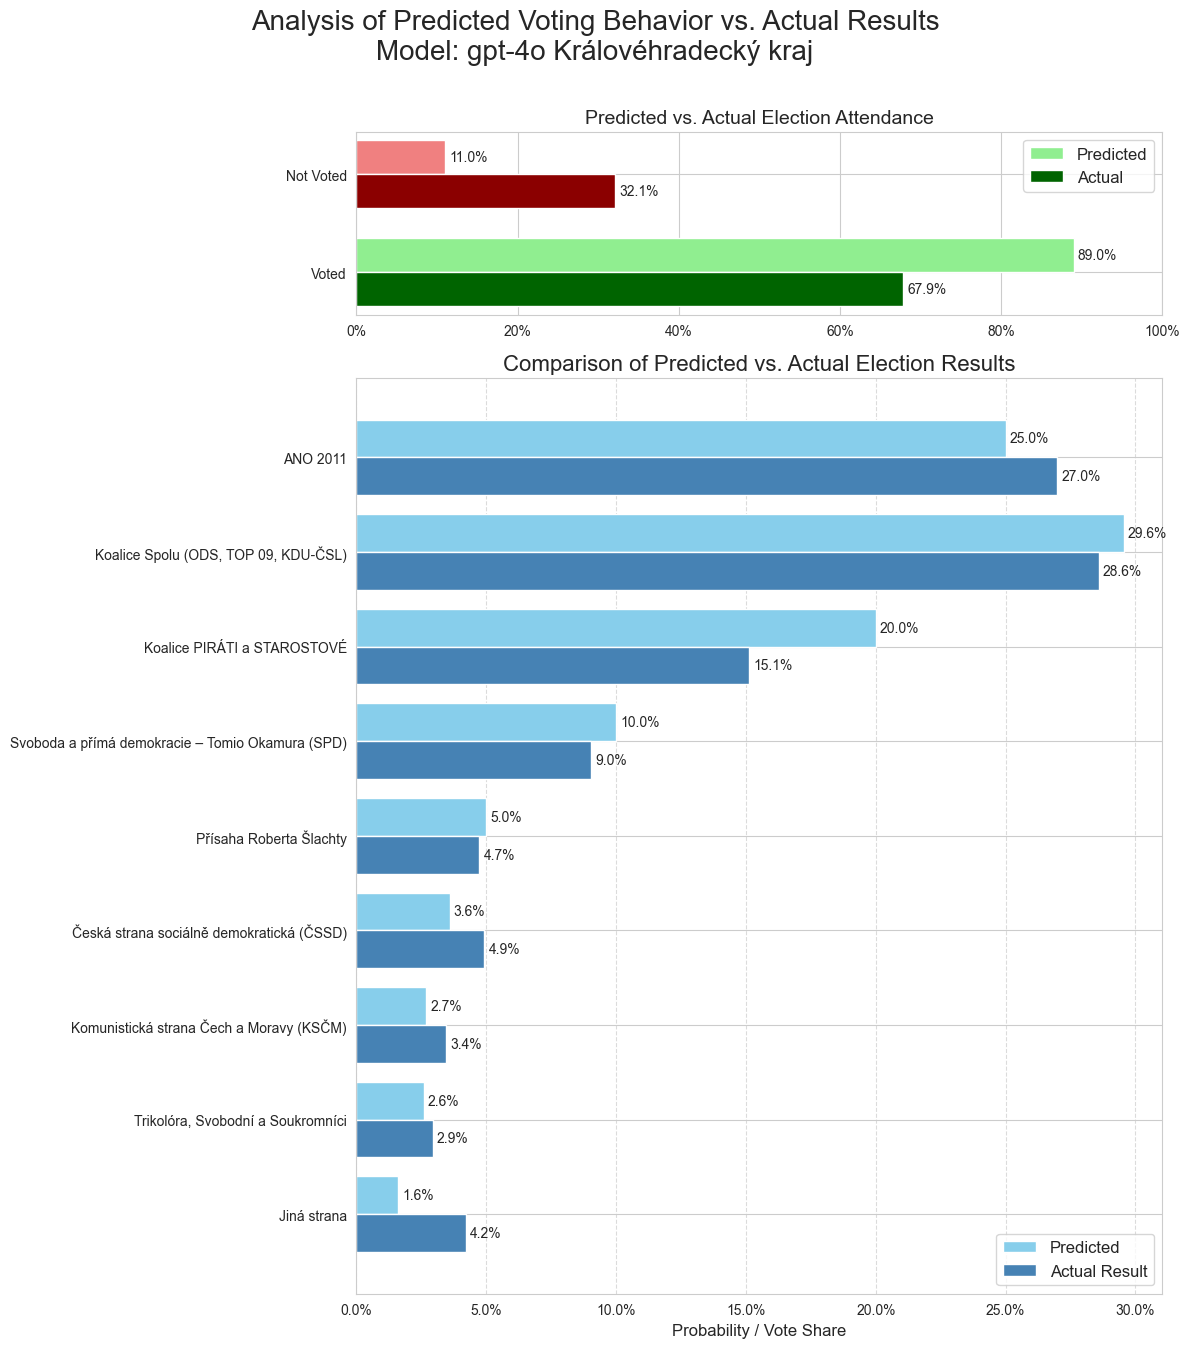

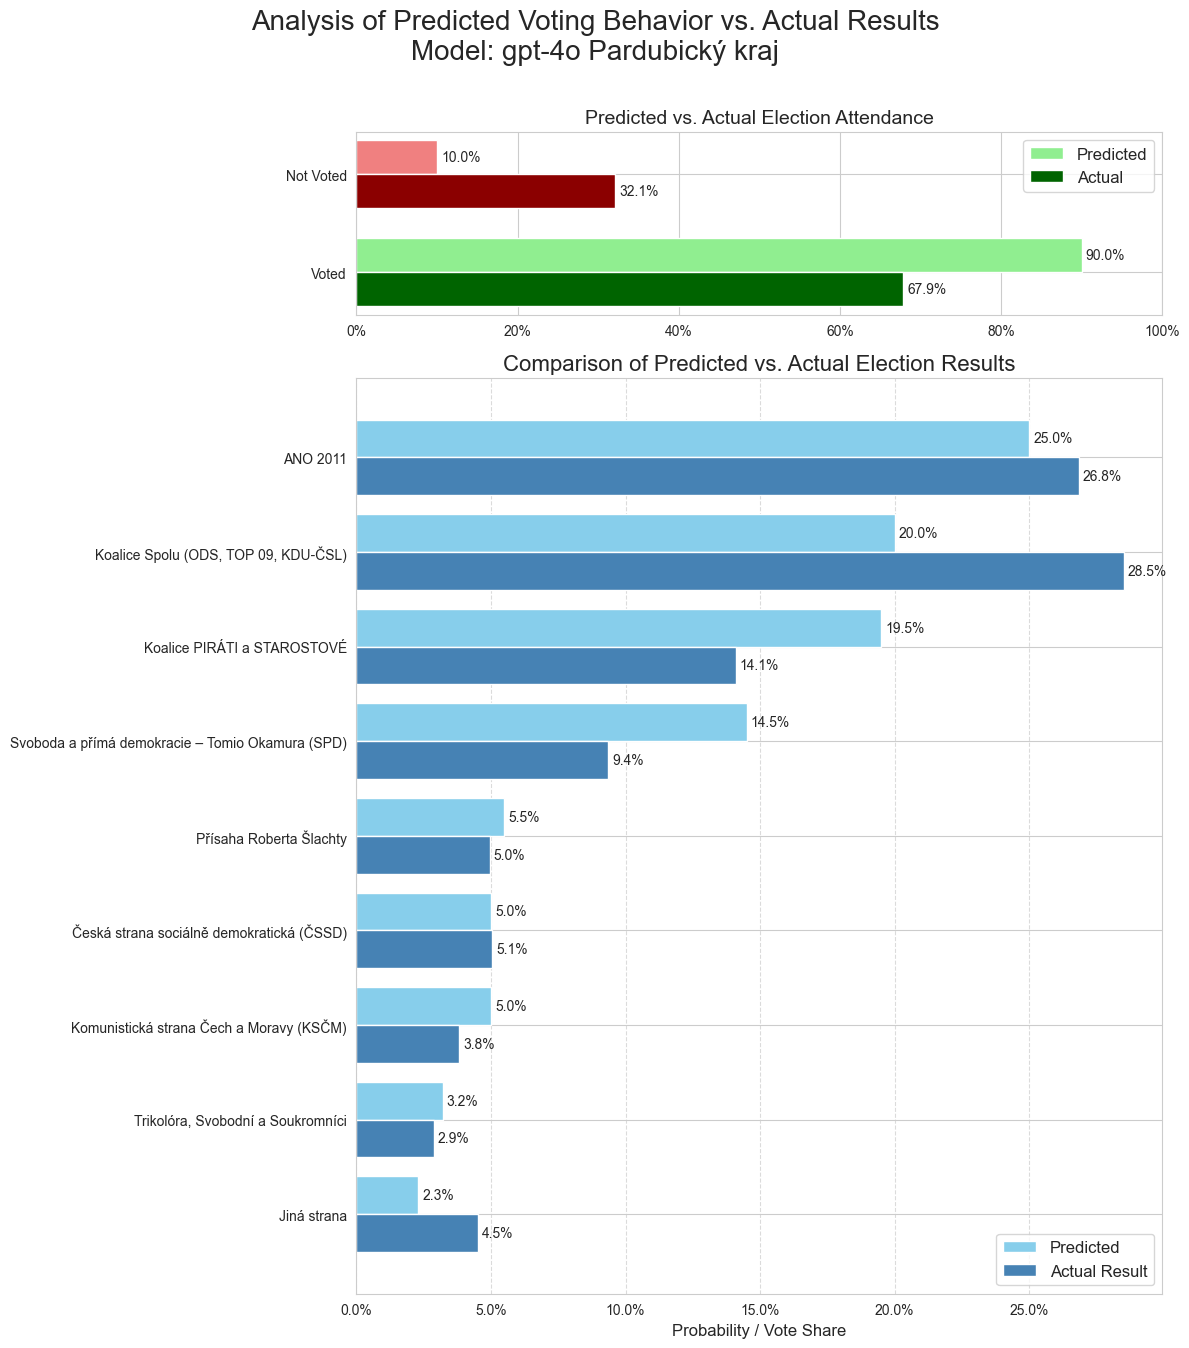

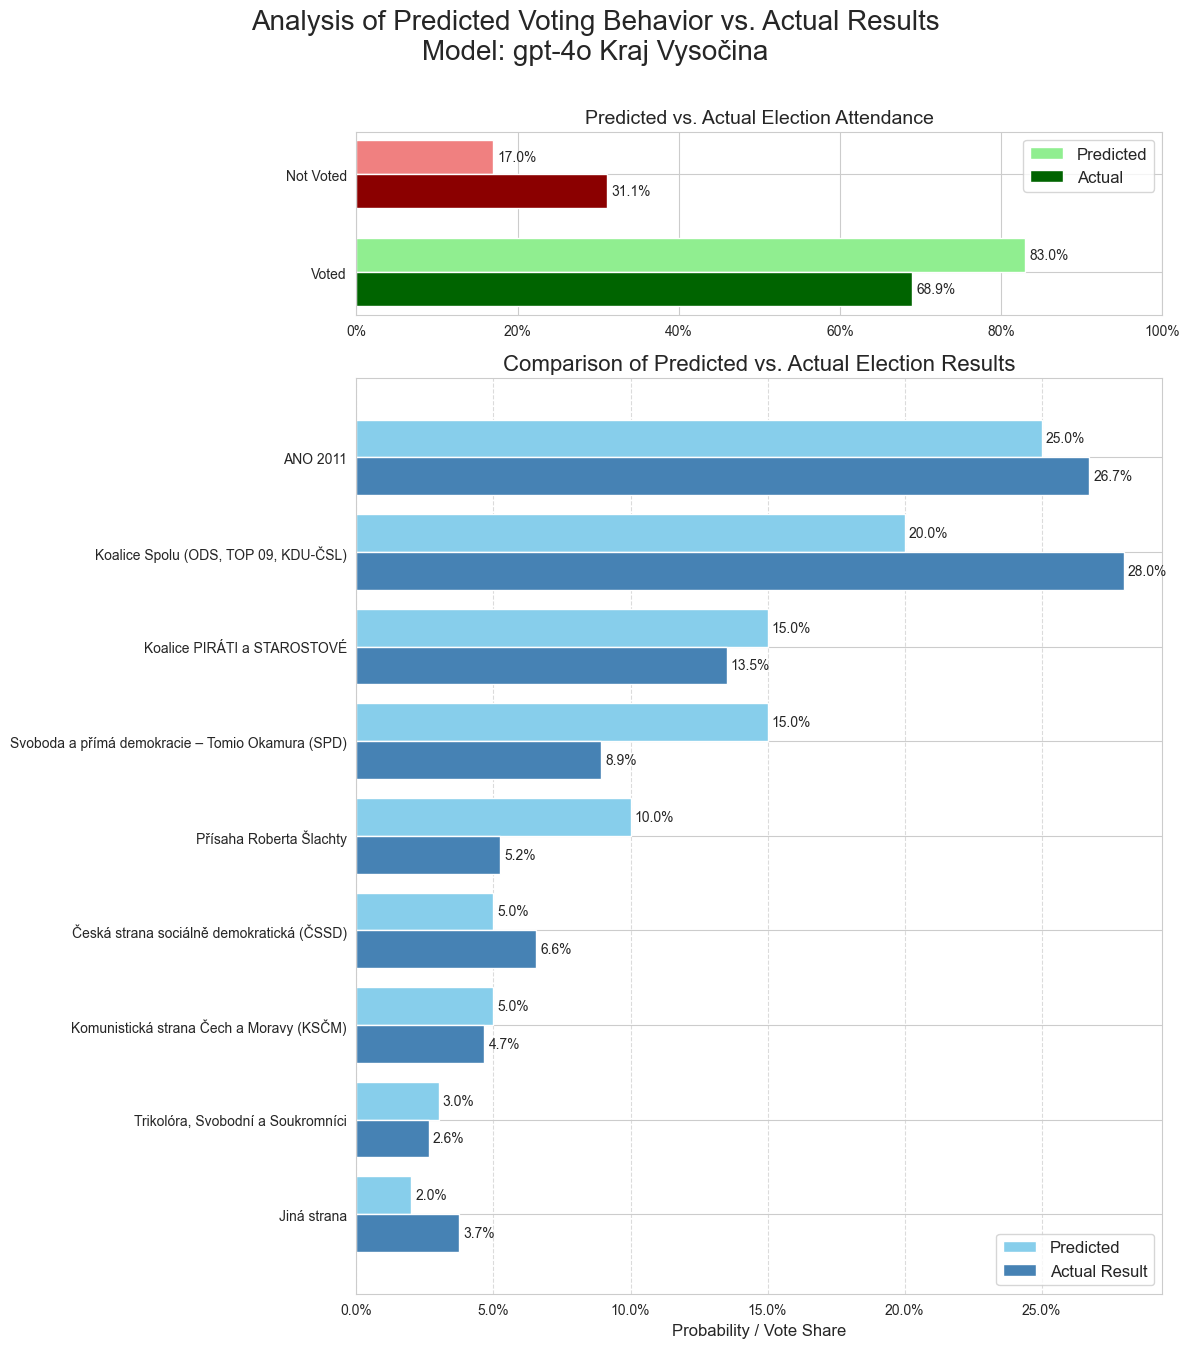

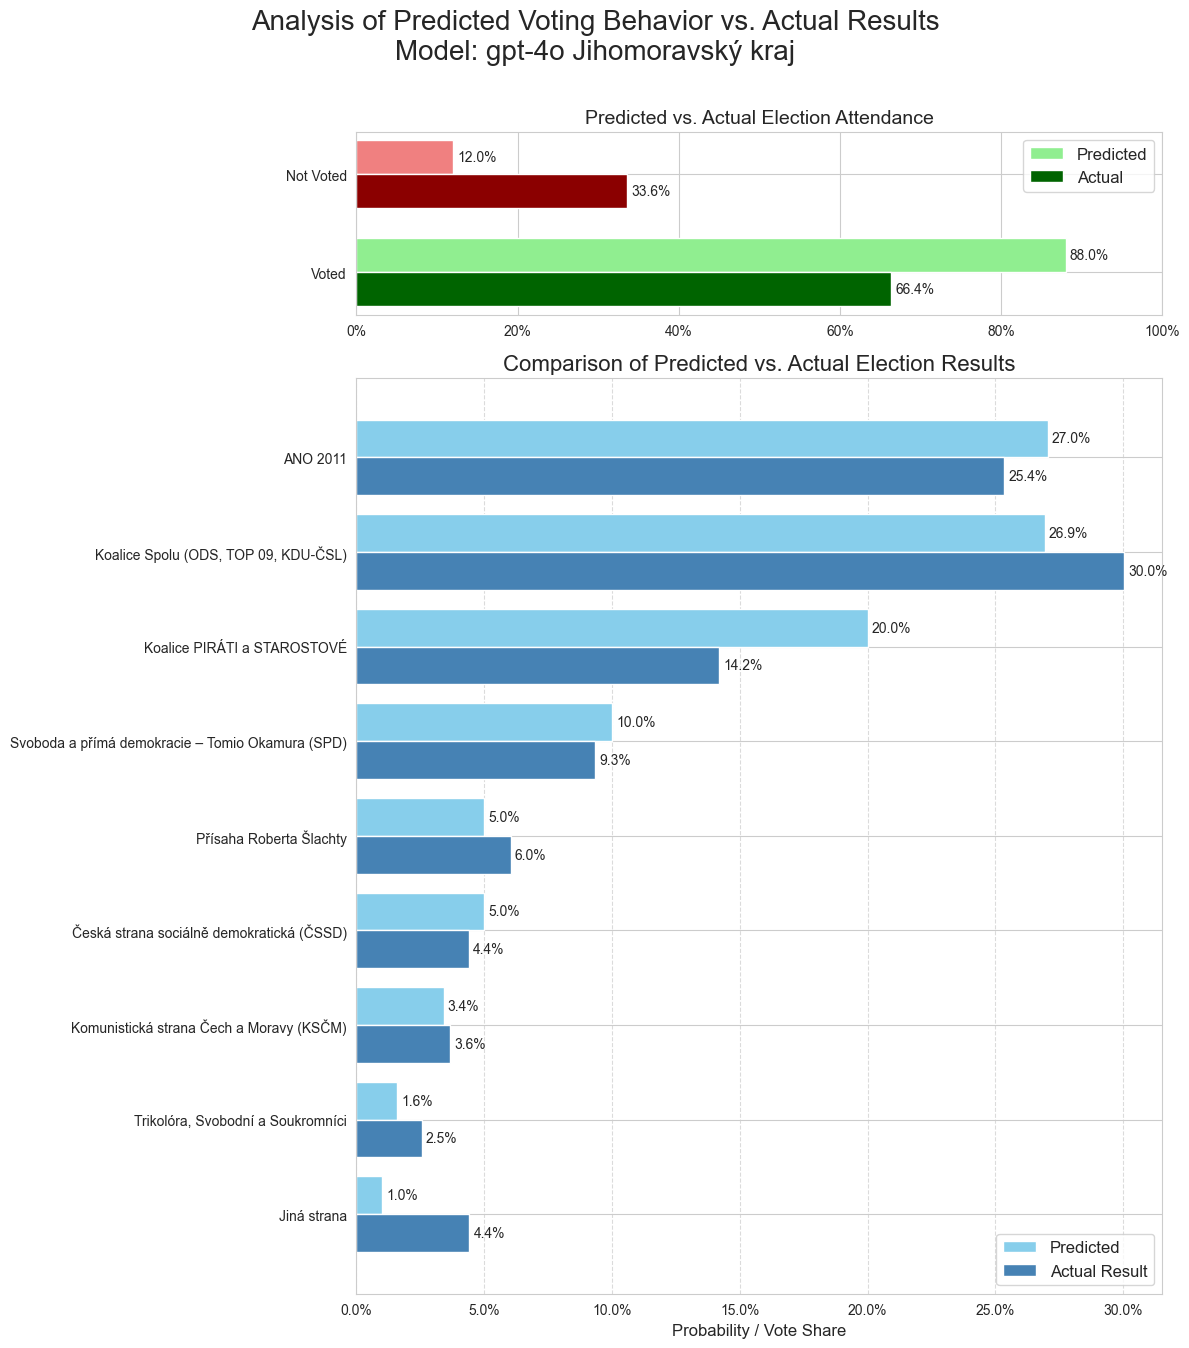

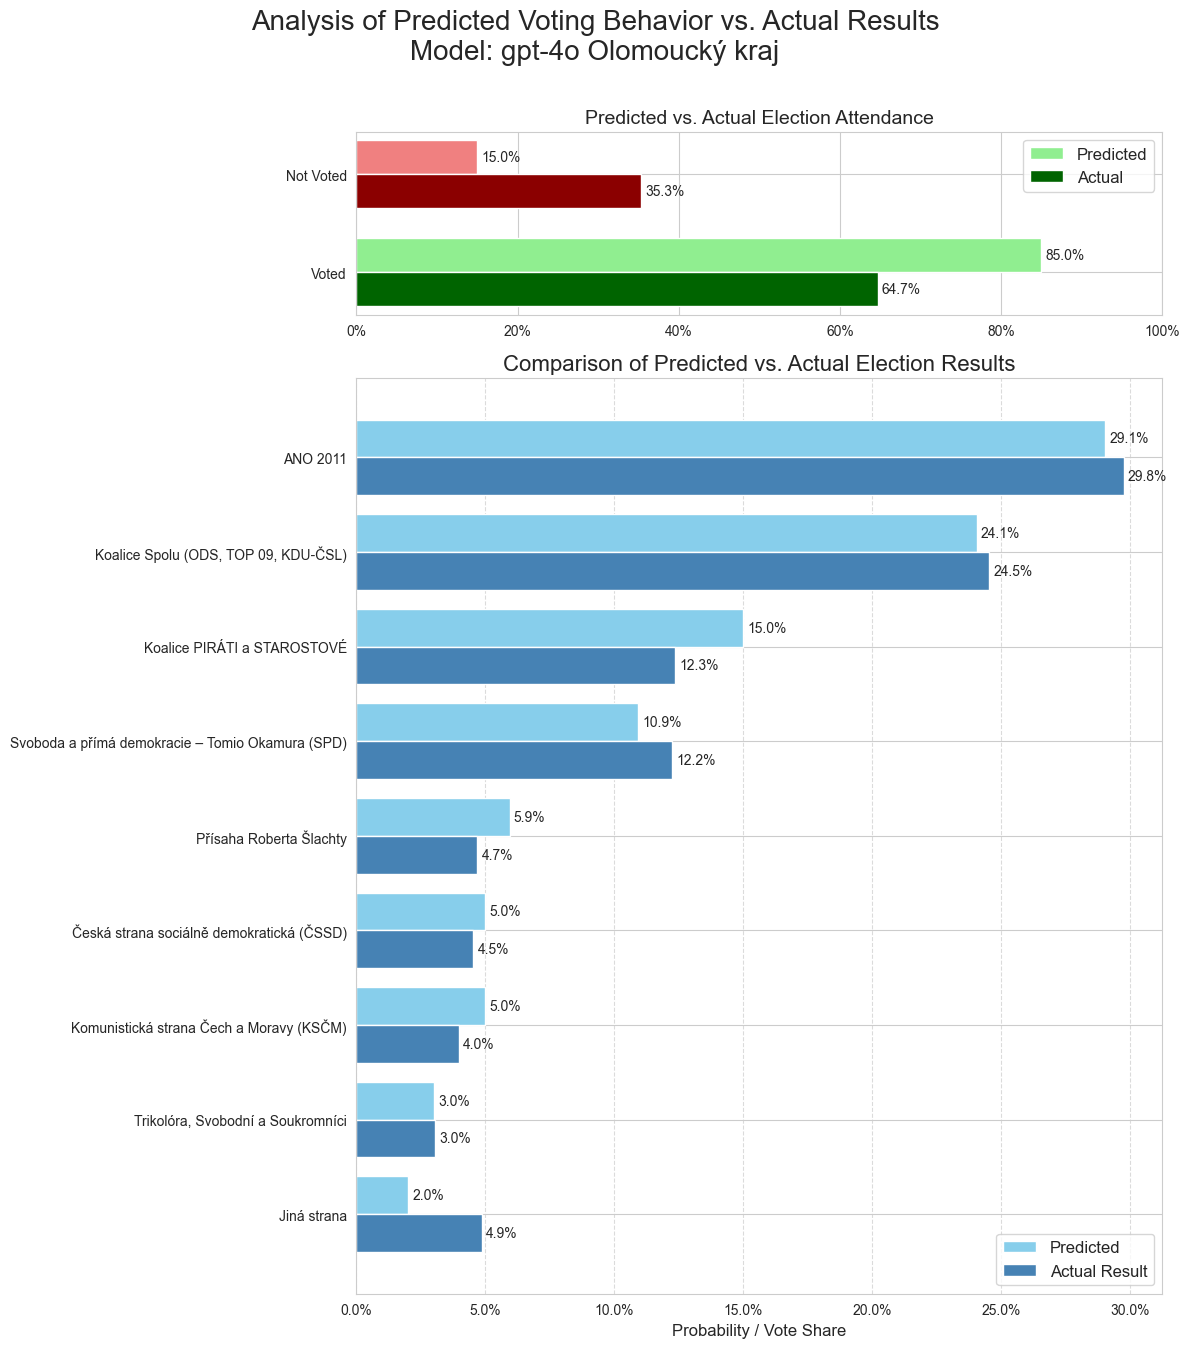

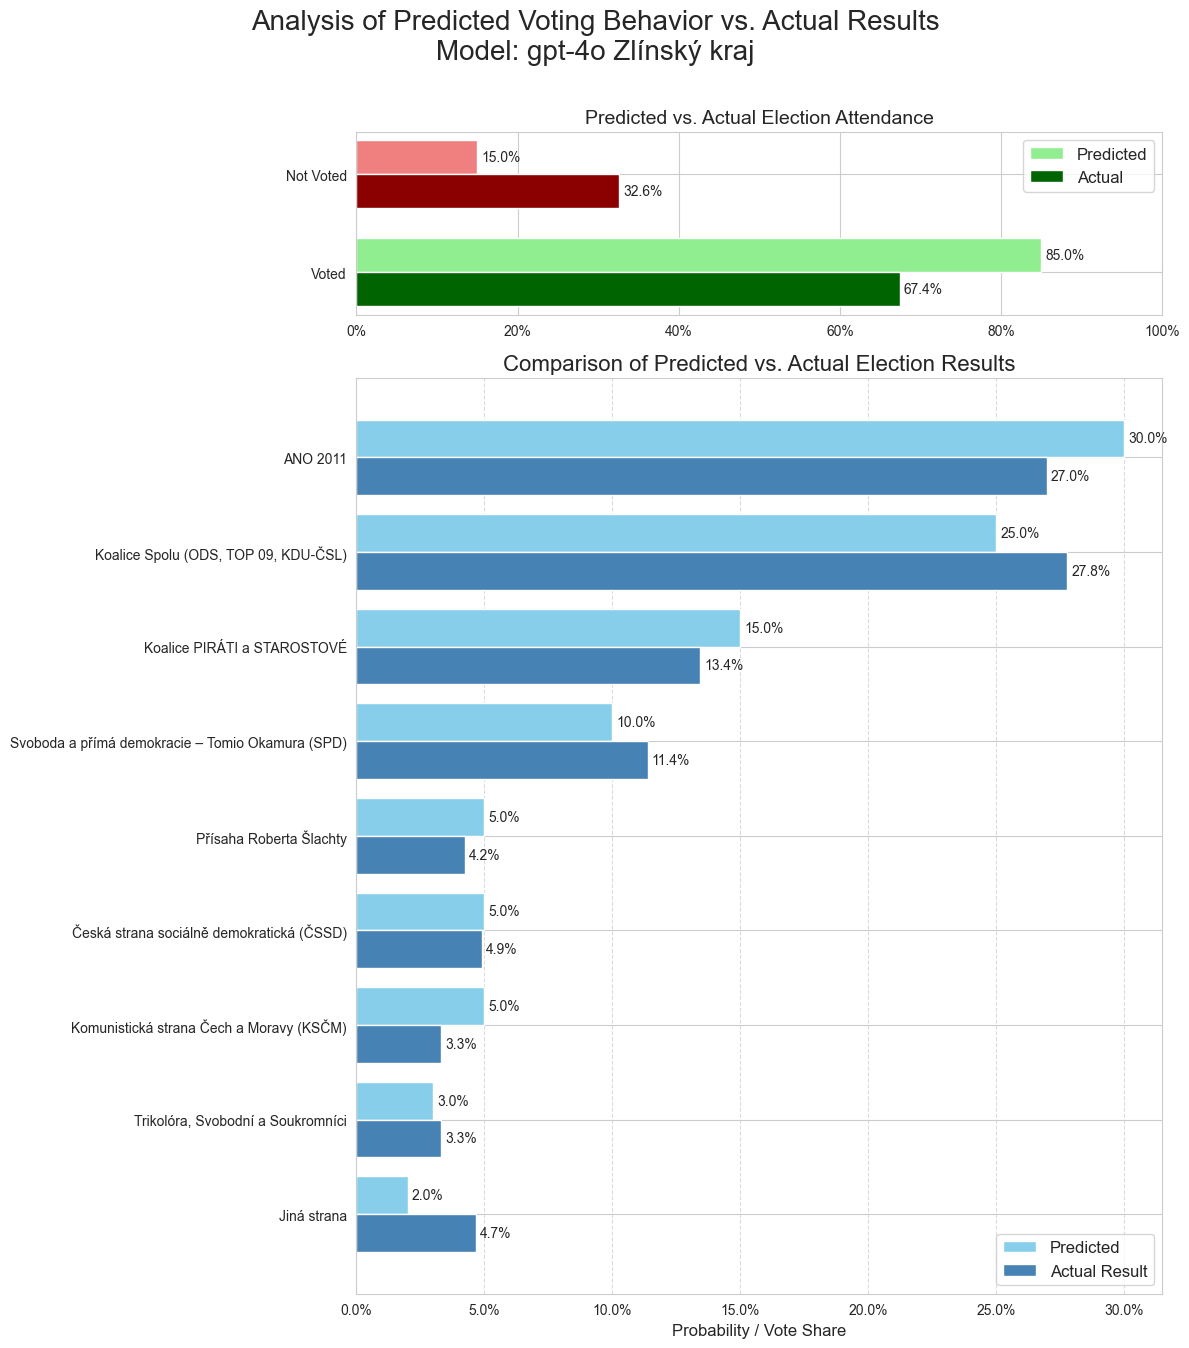

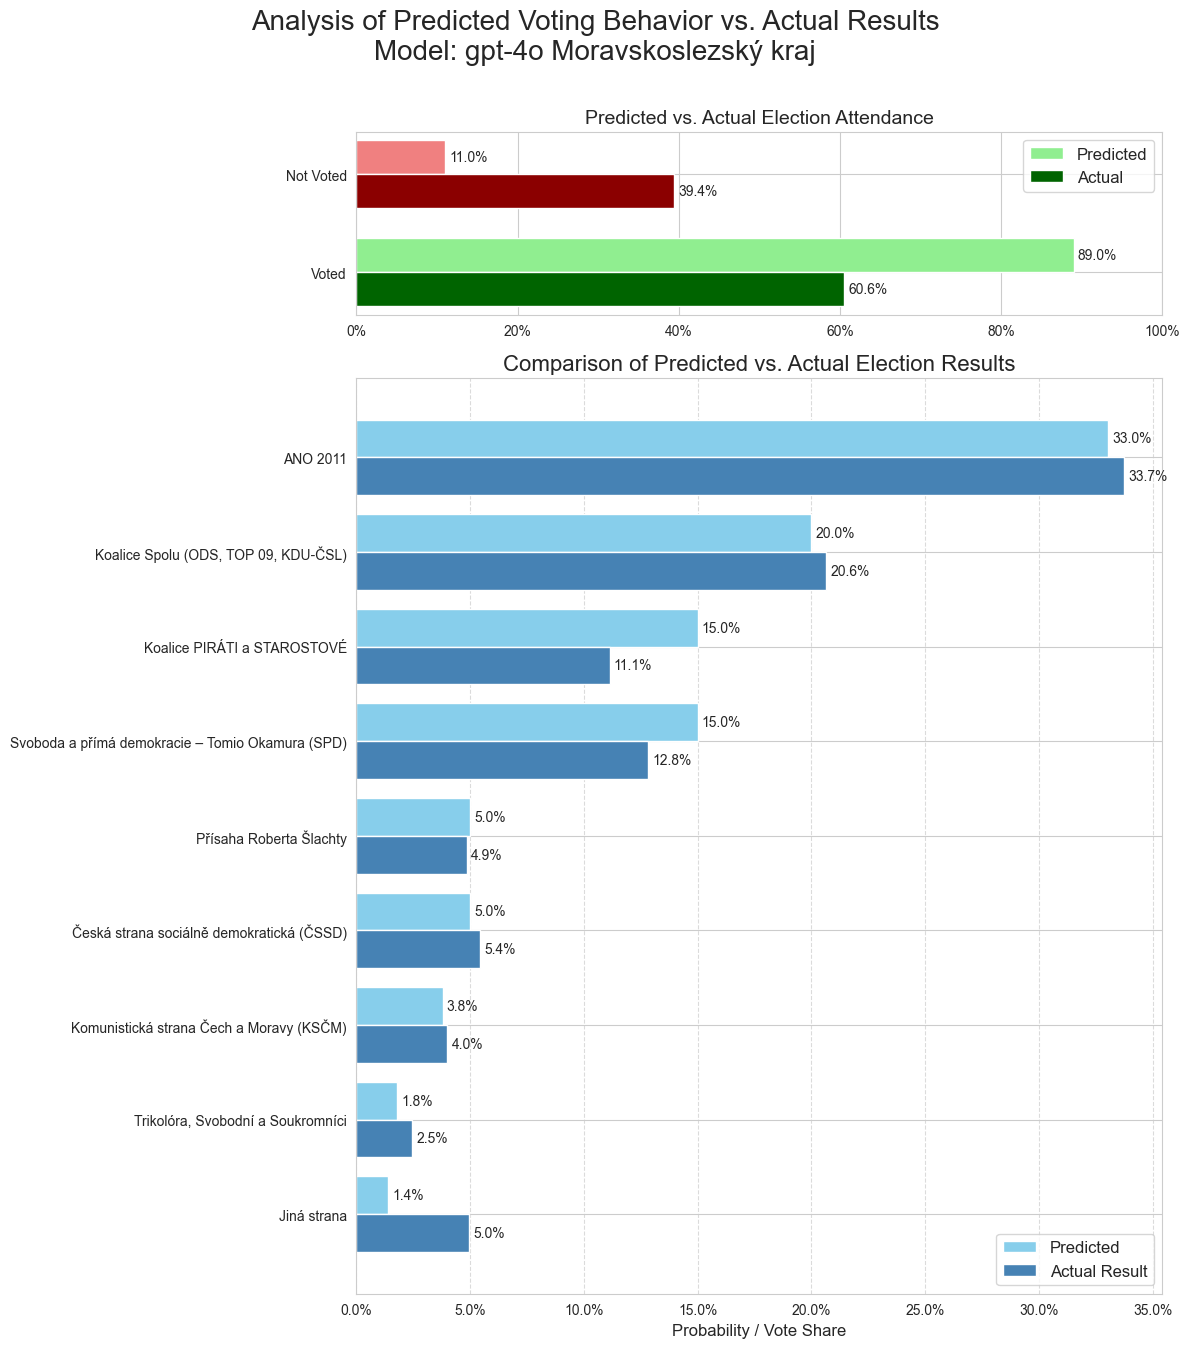

In [10]:
latent_results_df = pd.read_csv(f"results/LatentPreferences_{MODEL}_{prompt.__name__}.csv")
actual_results_df = Data_Utils.load_actual_results()

for region in ["Česko"] + Data_Utils.REGIONS:
     pred = latent_results_df[latent_results_df['region'] == region].iloc[0]
     actual = actual_results_df[actual_results_df["region"] == region].iloc[0]
     fig = Visualization_Utils.visualize_comprehensive_results(
        pred,
        actual,
        Data_Utils.PARTY_COLUMNS_2021,
        model_name=MODEL + " " + region, actual_is_claimed=False
    )

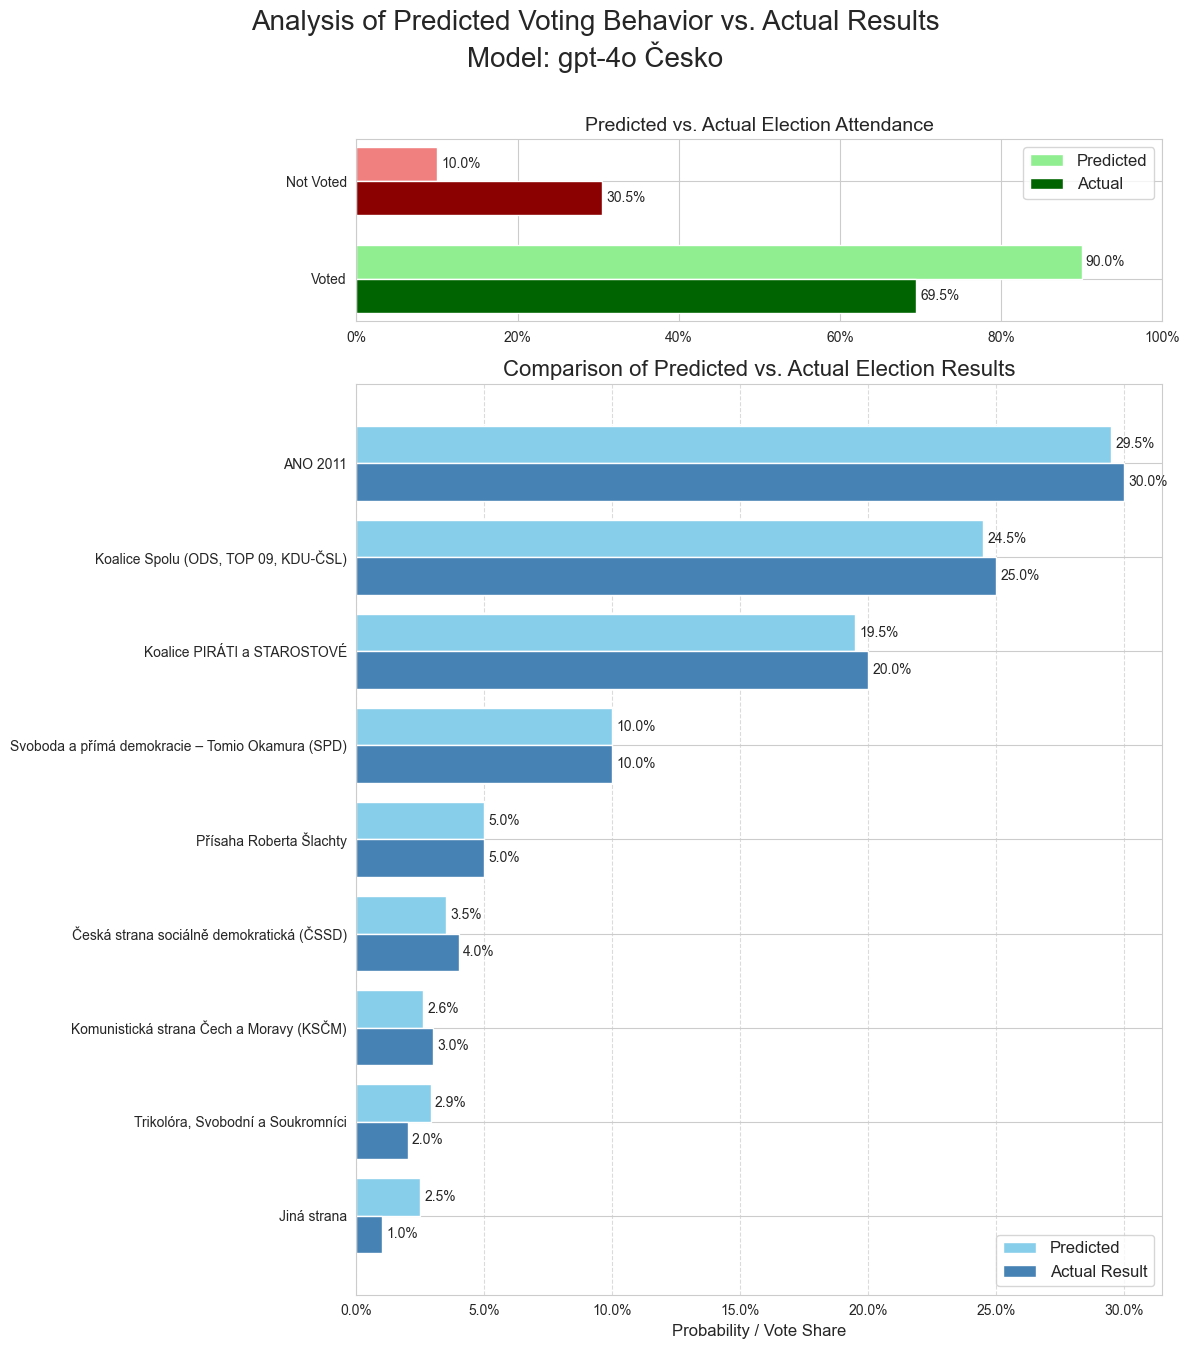

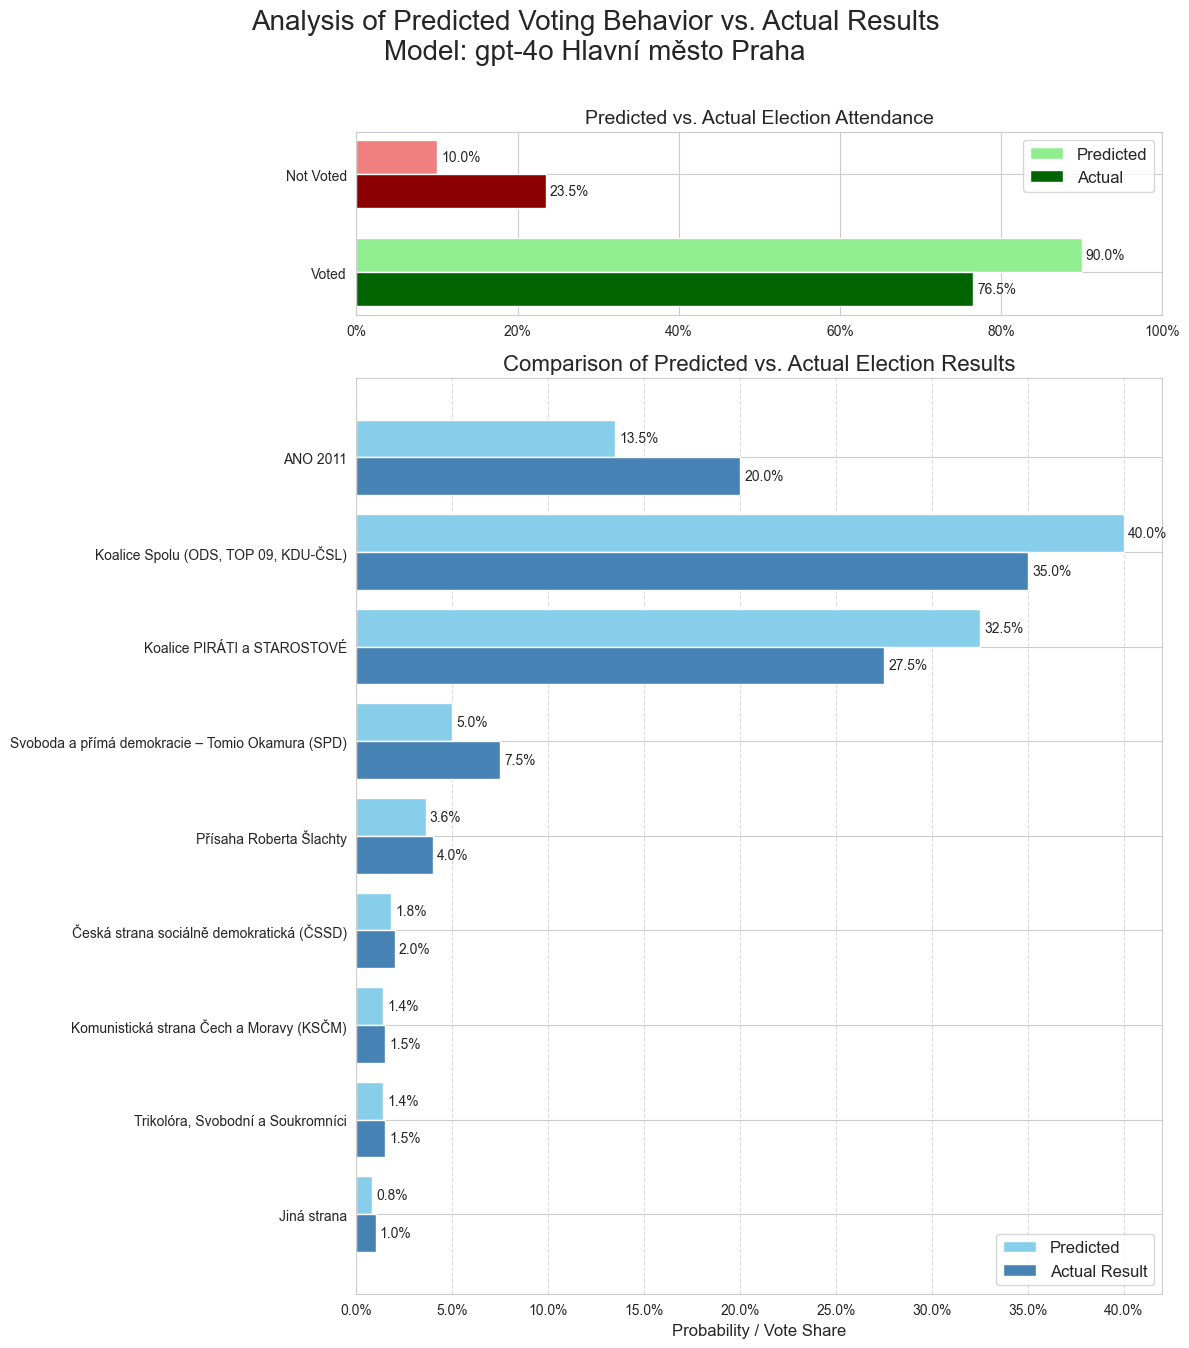

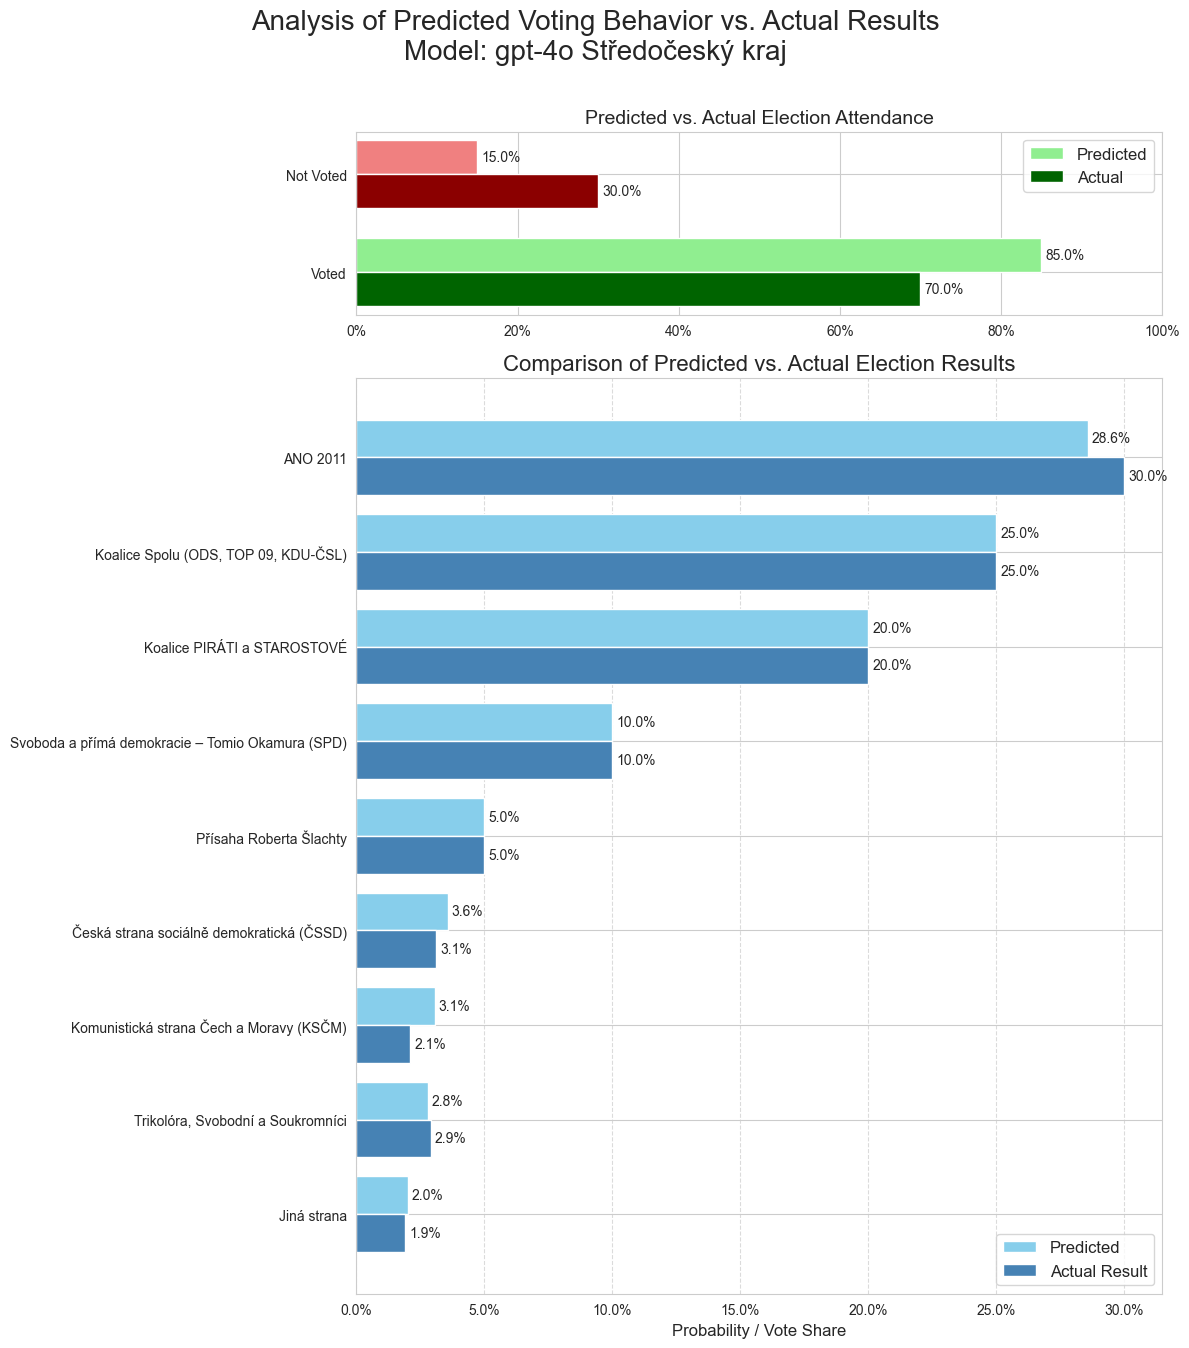

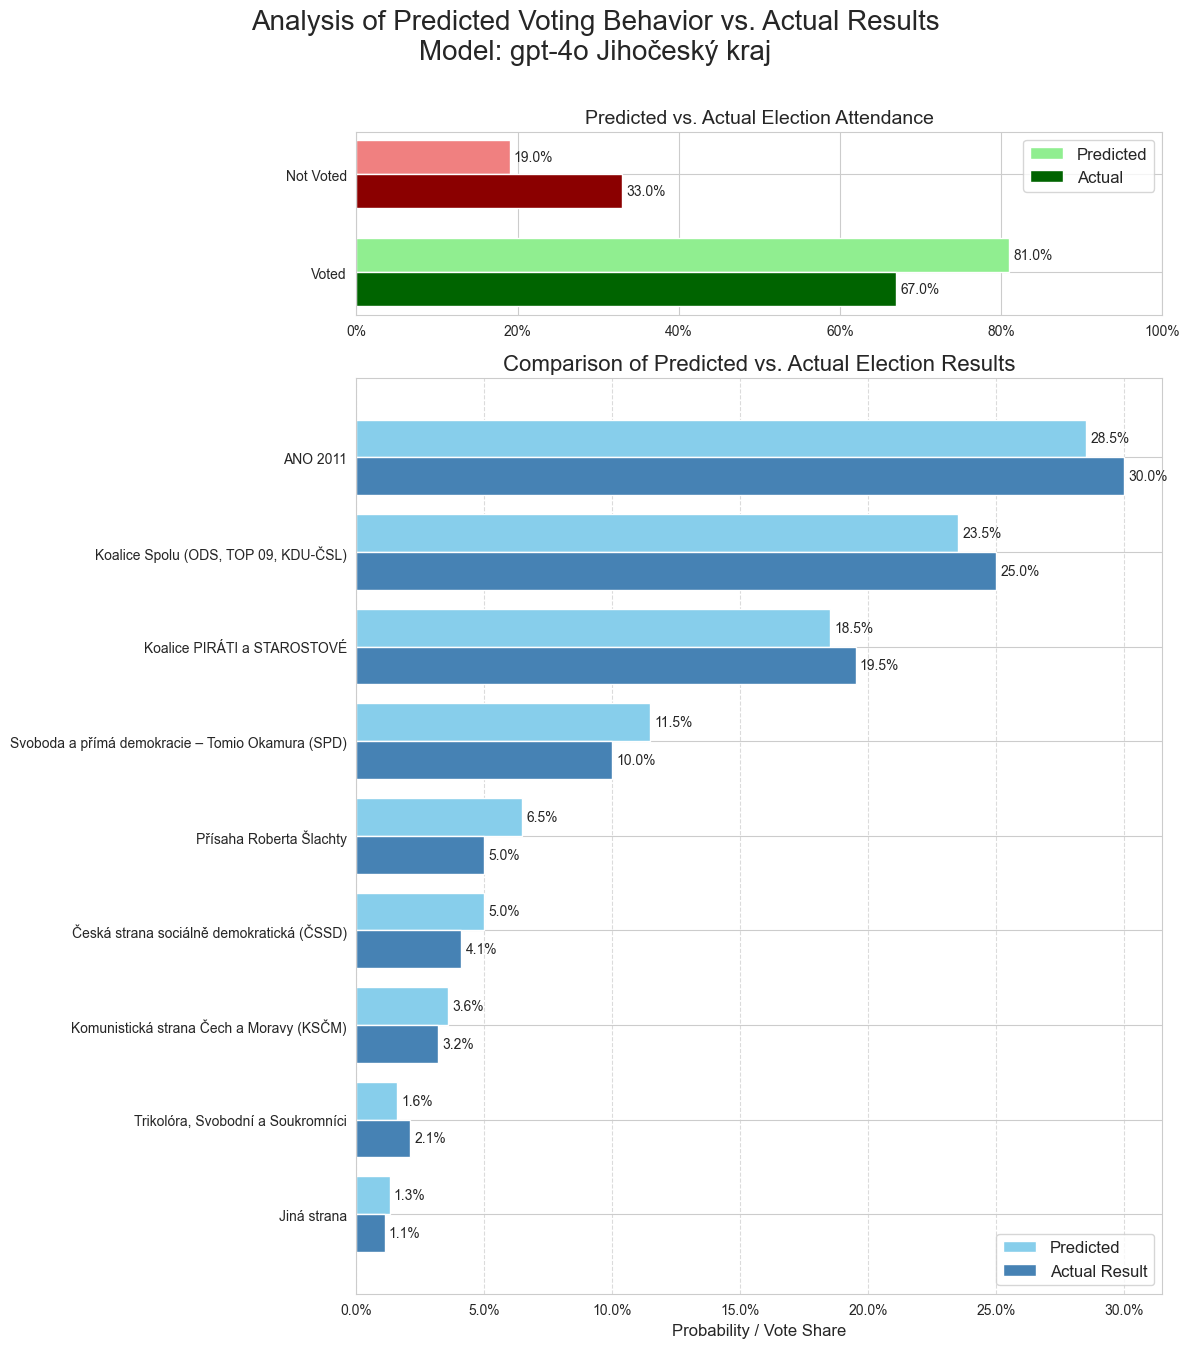

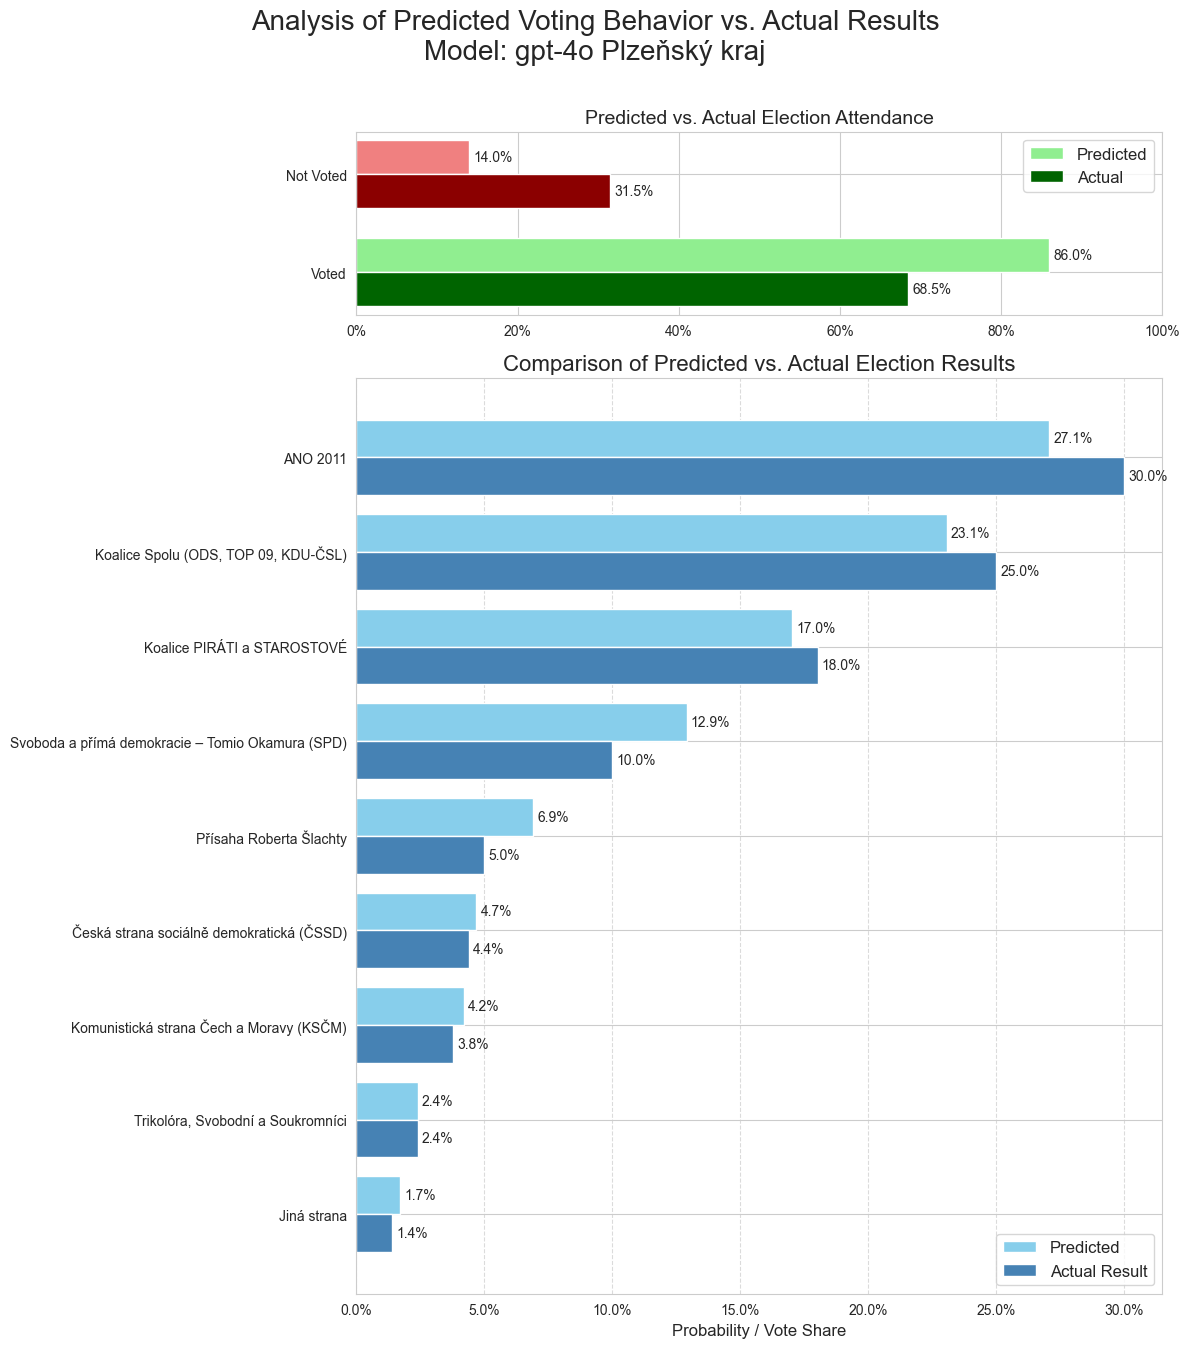

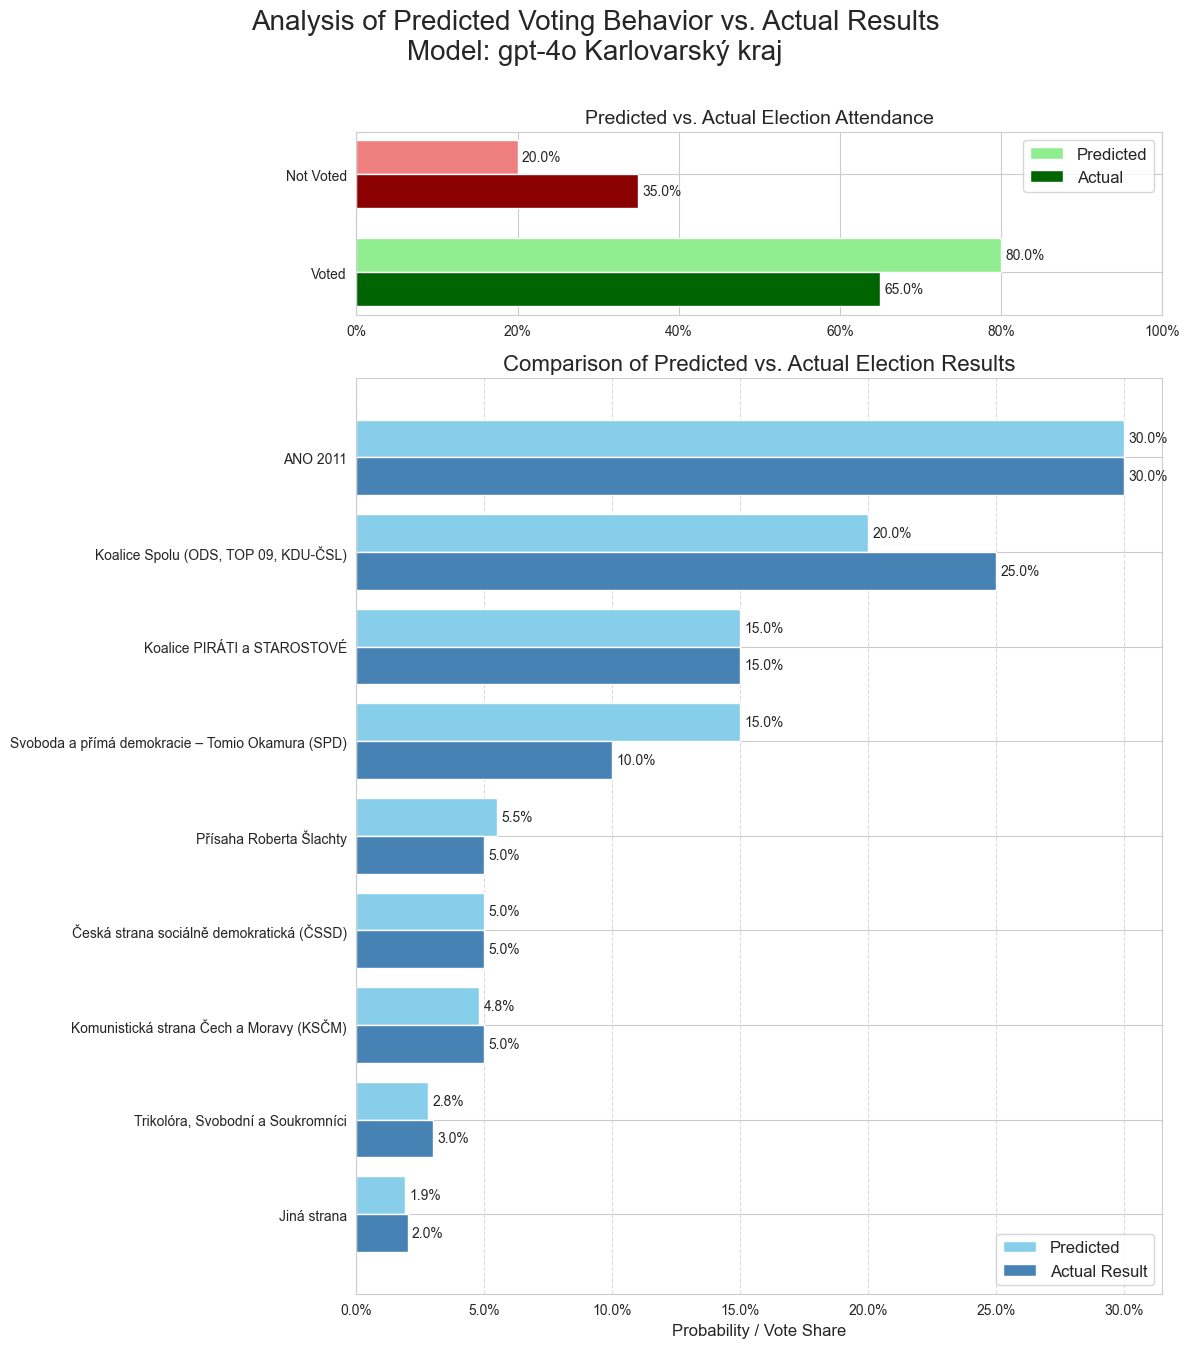

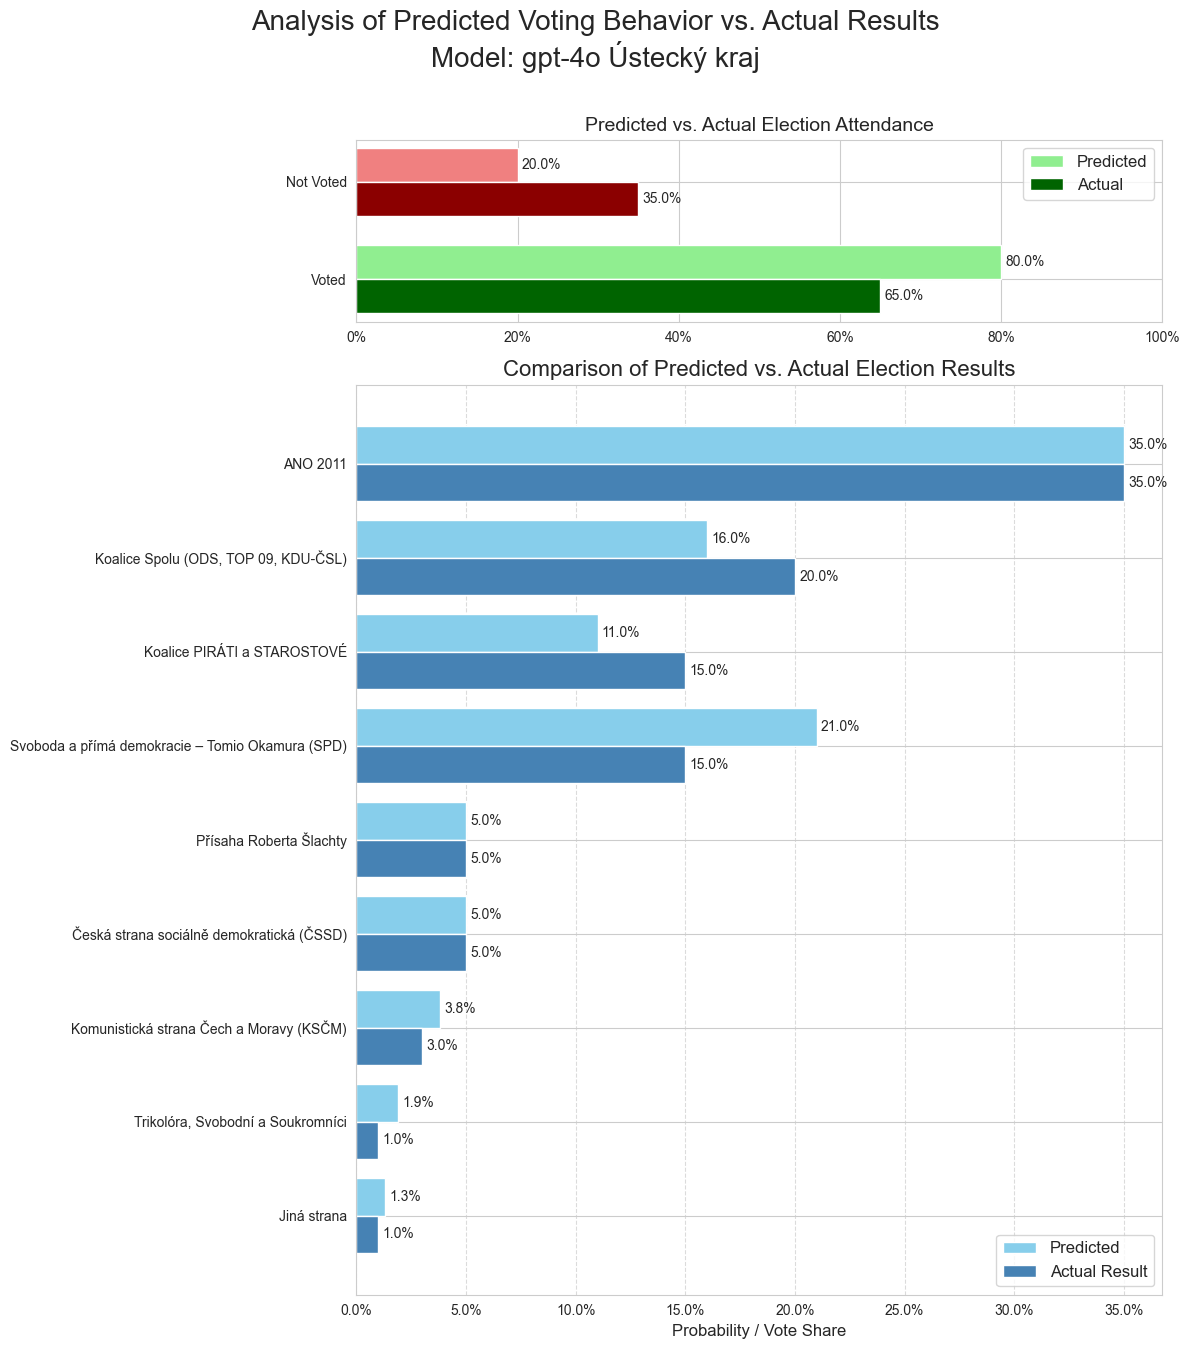

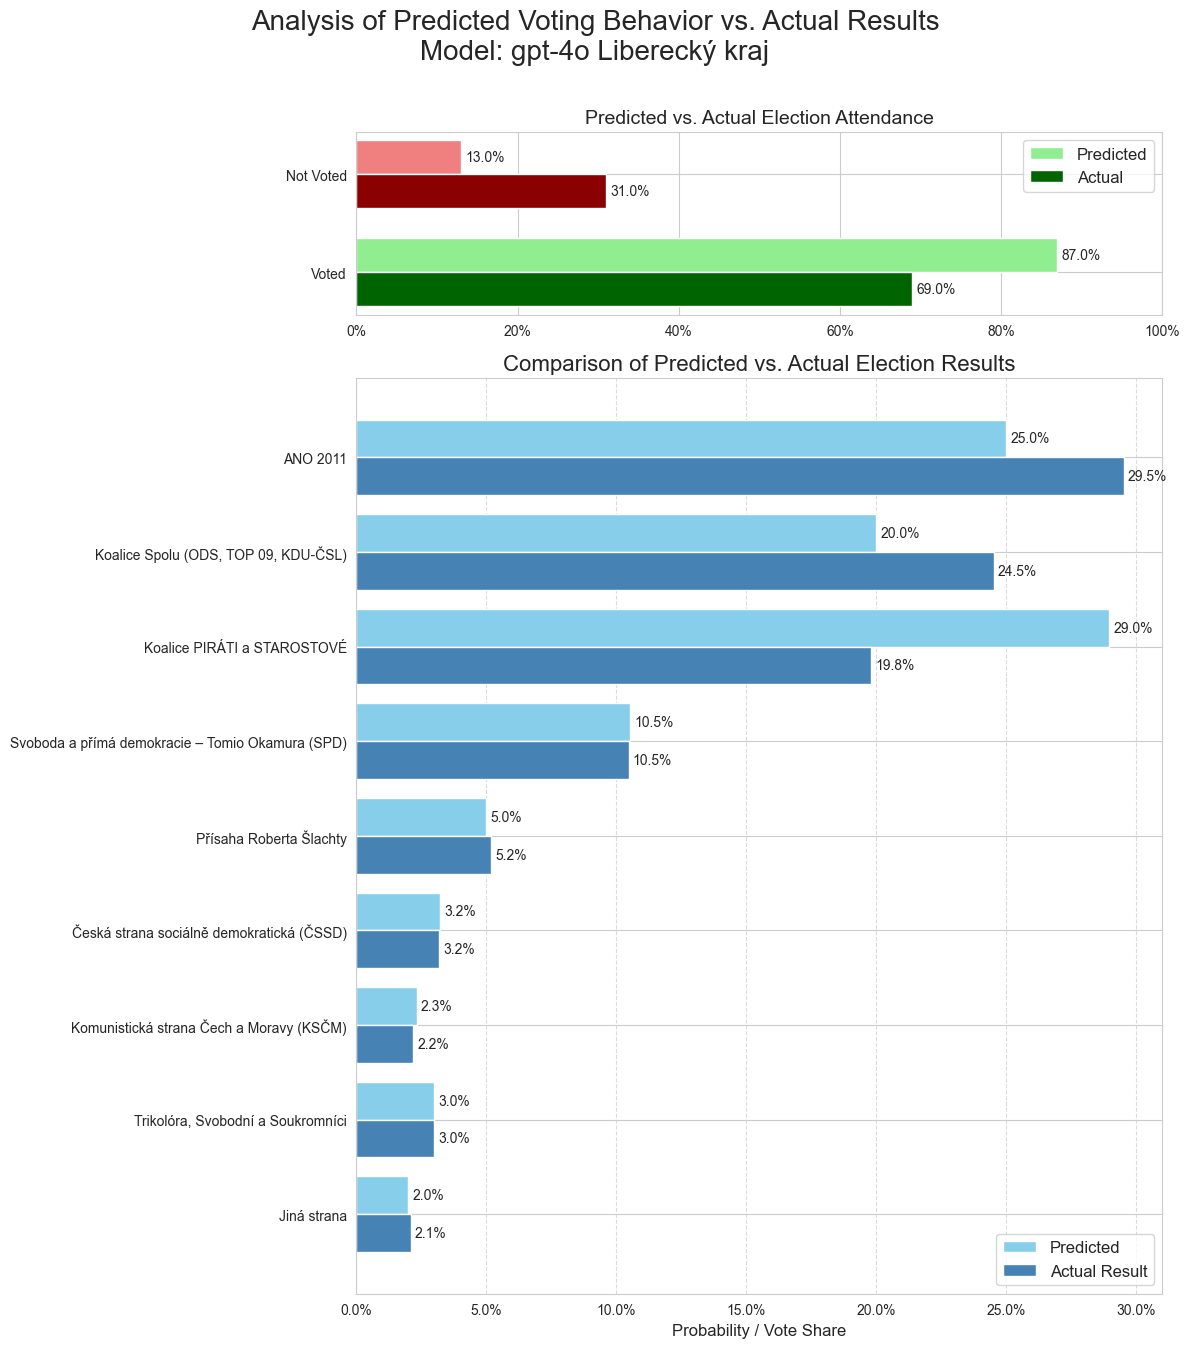

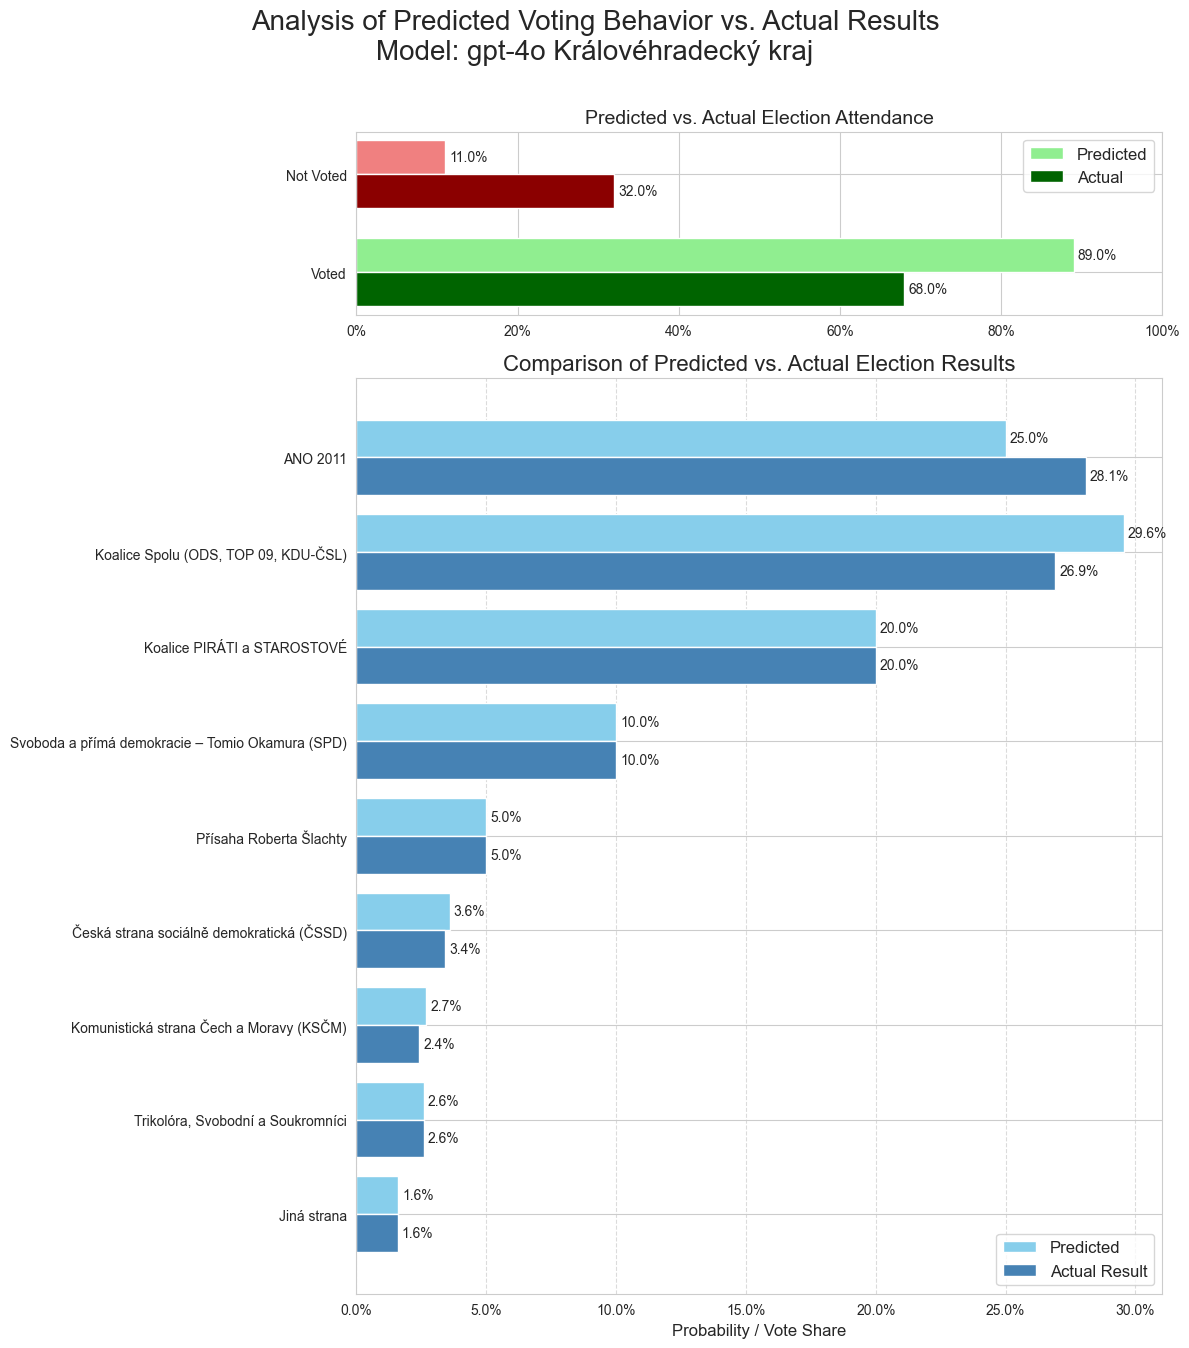

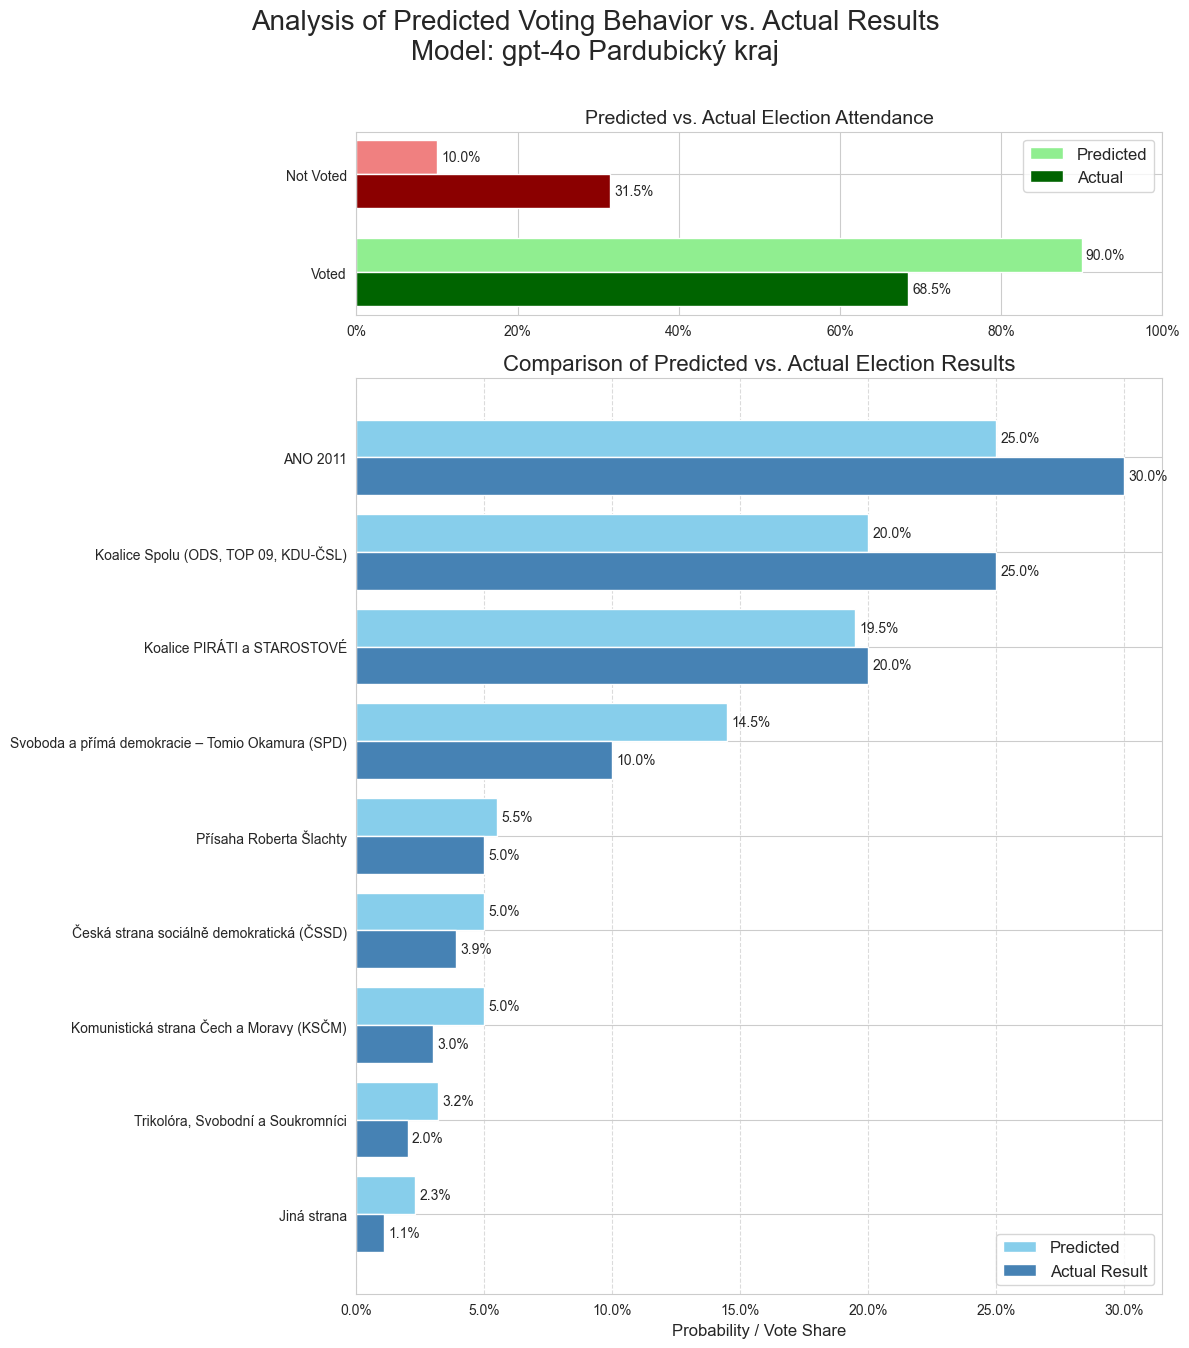

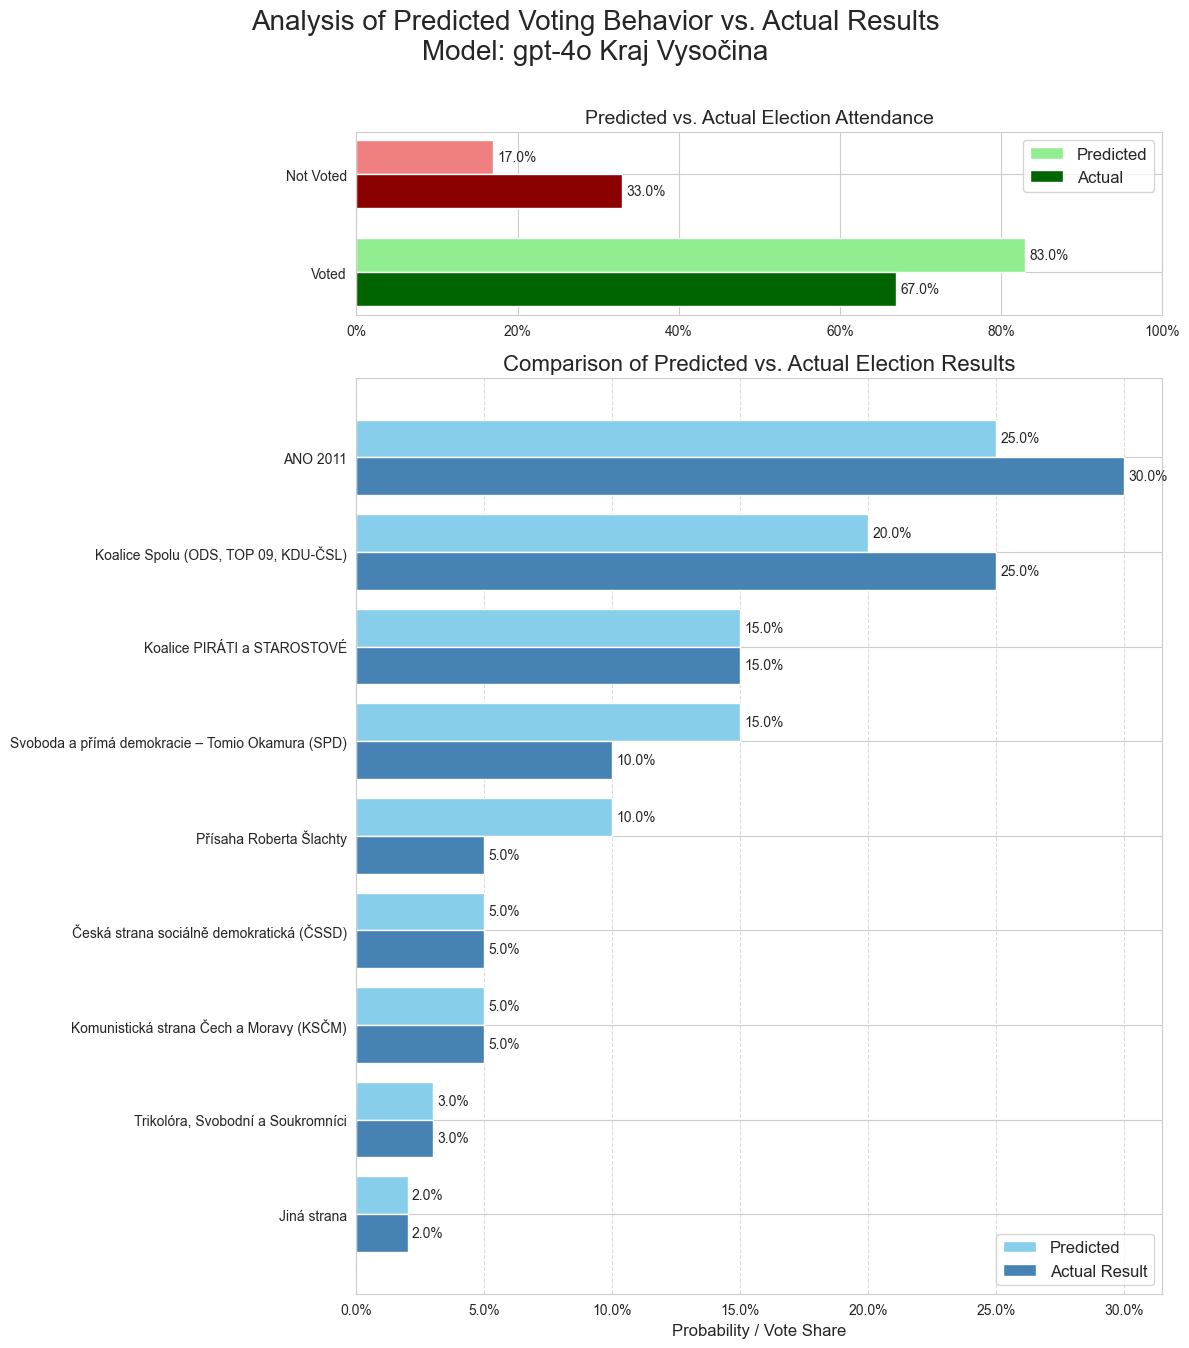

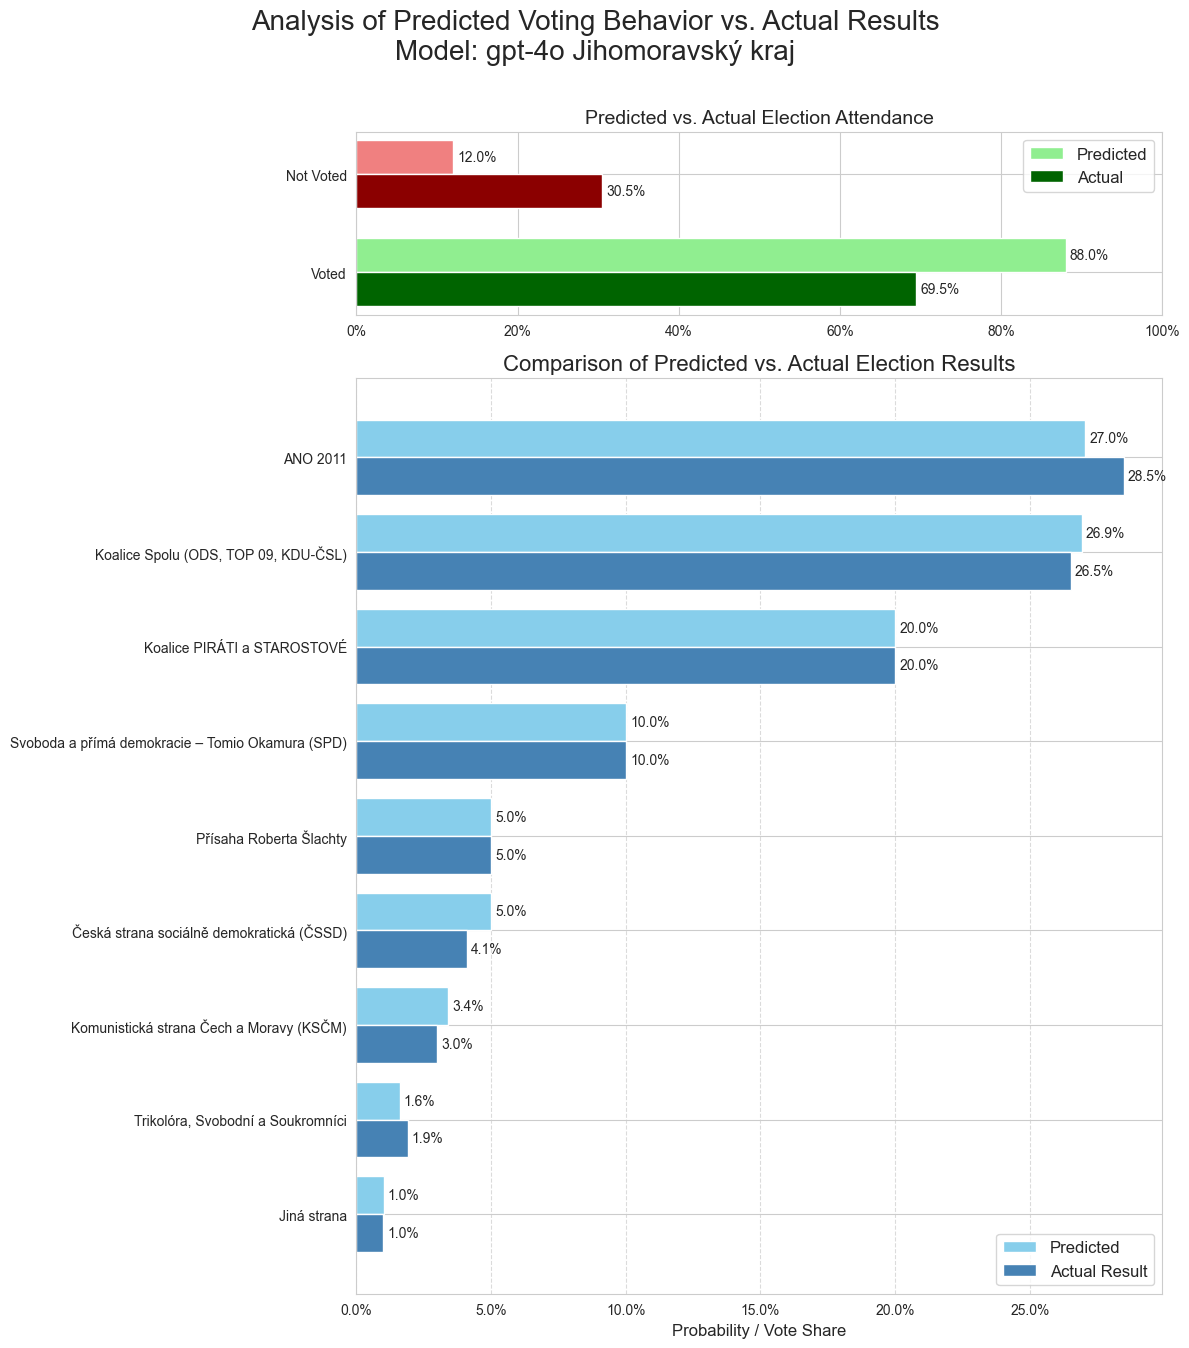

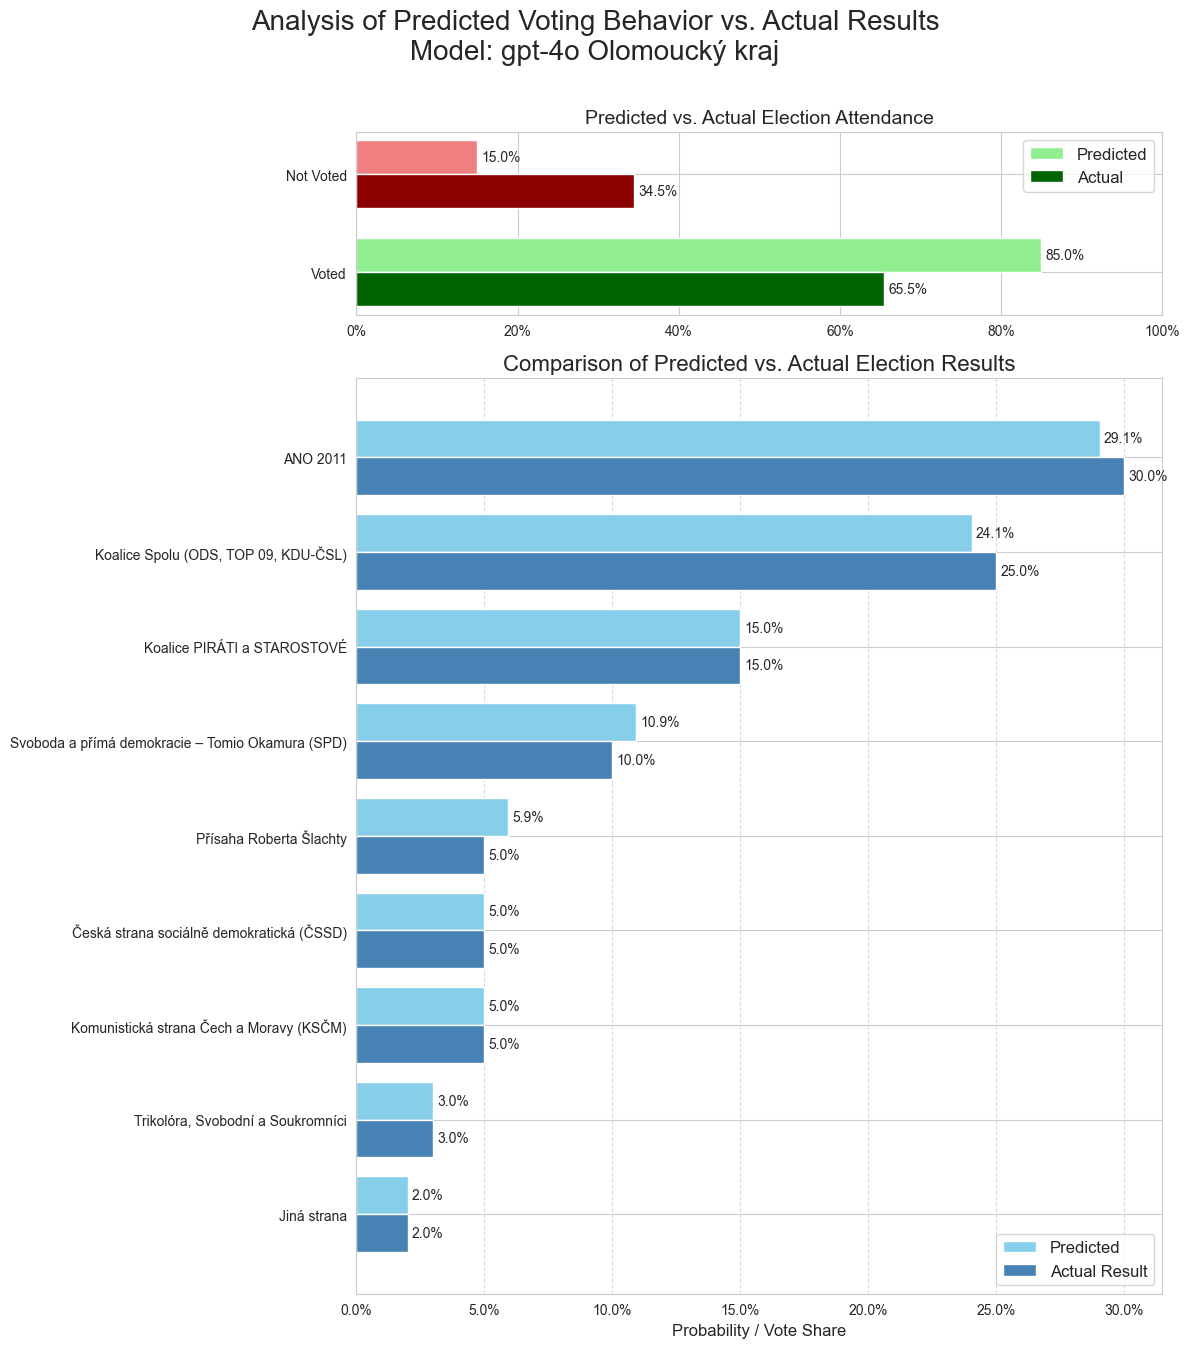

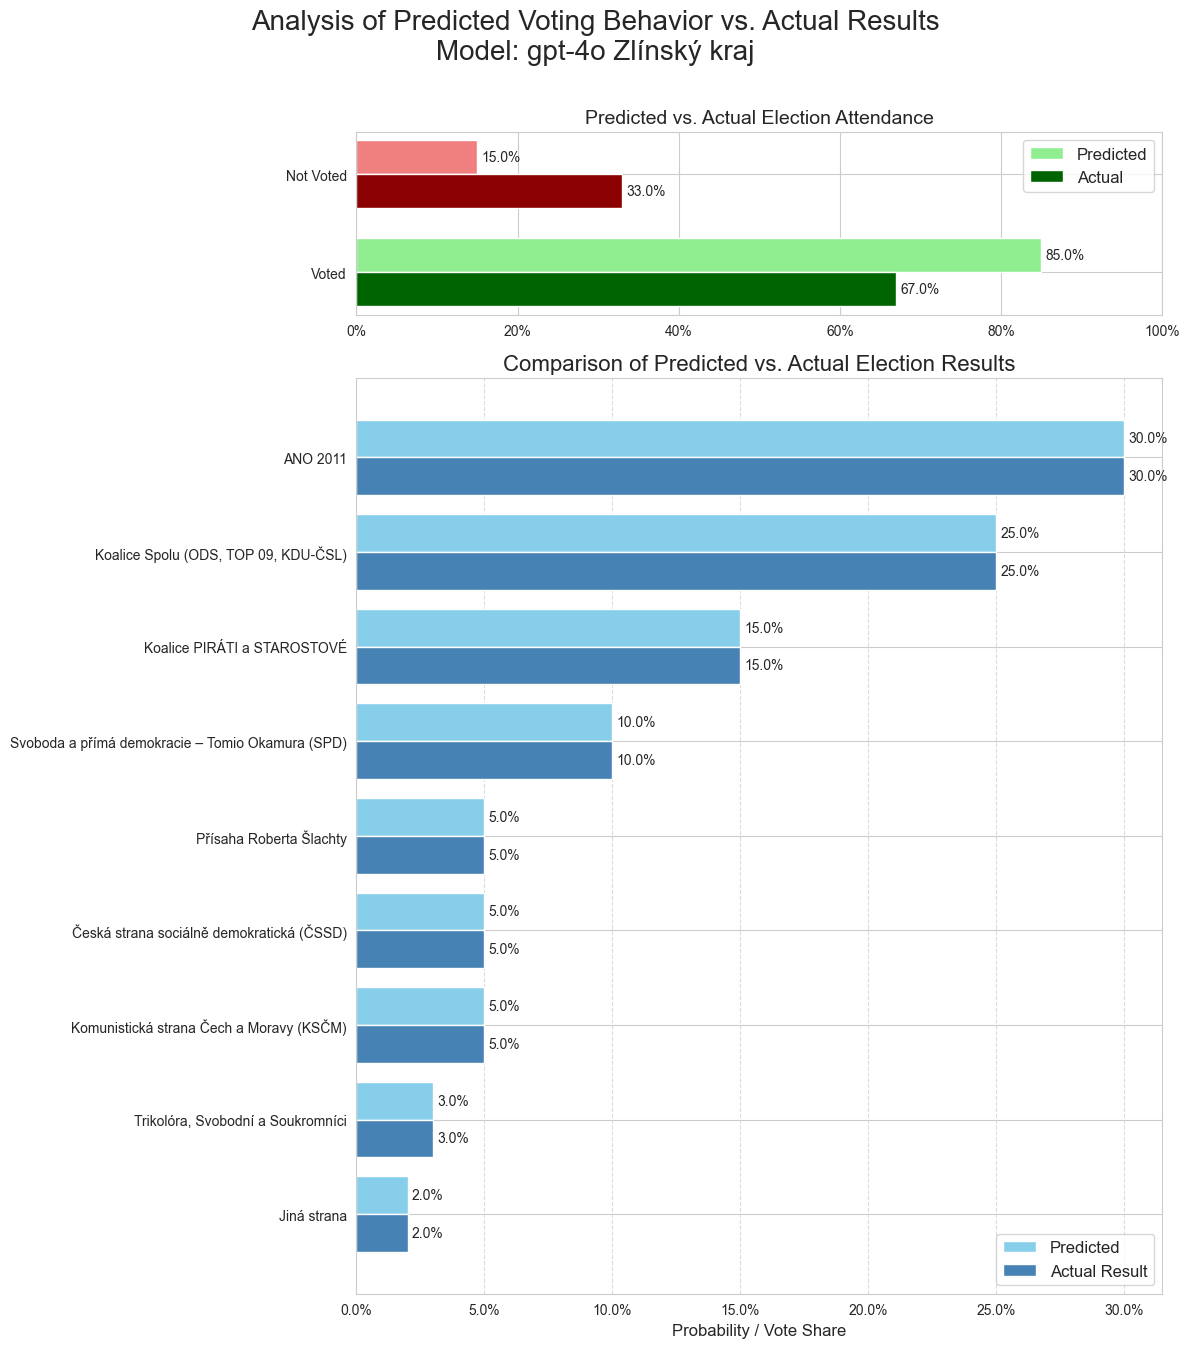

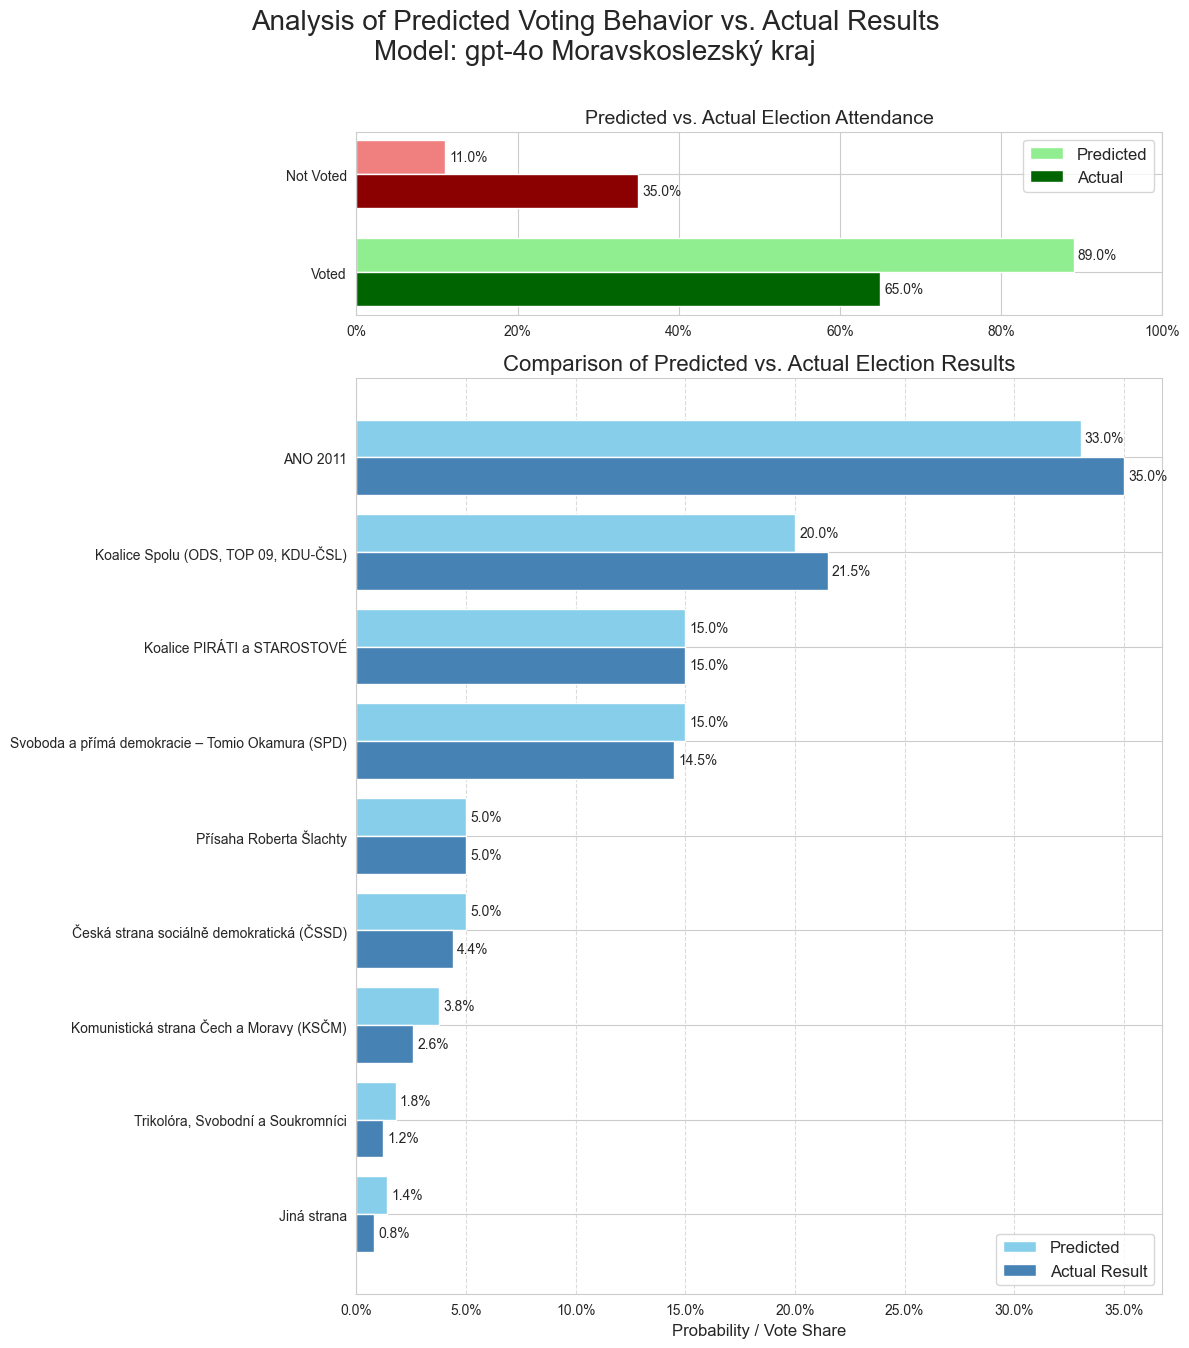

In [9]:
cit = pd.read_csv(f"results/LatentPreferences_{MODEL}_{citizen_prompt.__name__}.csv")
dir = pd.read_csv(f"results/LatentPreferences_{MODEL}_{direct_prompt.__name__}.csv")


for region in ["Česko"] + Data_Utils.REGIONS:
     pred = cit[cit['region'] == region].iloc[0]
     actual = dir[dir["region"] == region].iloc[0]
     fig = Visualization_Utils.visualize_comprehensive_results(
        pred,
        actual,
        Data_Utils.PARTY_COLUMNS_2021,
        model_name=MODEL + " " + region, actual_is_claimed=False
    )